# EEG_40 — Caratterizzazione dei fenotipi a livello di **soggetto**, stratificata per **banda**

**Obiettivo (meeting Iacomi, giu 2026).** Finora i fenotipi C0/C1 sono stati *scoperti* e
*validati* a livello di trial (ARI trial-level, stabilità inter-sessione). Questo notebook
risponde alla domanda complementare: **cosa distingue neurofisiologicamente C0 da C1**, a
livello di soggetto e separando per banda di frequenza.

Pipeline (= paper Iacomi et al. 2026, di cui D. Uras è coautore):

1. per ogni soggetto, media **tutti** i trial `_img` → 1 profilo per soggetto;
2. media dentro il cluster → profilo C0 e profilo C1;
3. confronto C0 vs C1 con **effect size** (Cohen's d), non p-value (i p-value sono saturati
   su decine di migliaia di trial — cfr. EEG_23 §14).

Due famiglie di metriche, una per ciascuna ipotesi di fenotipo:

| Metrica | Cosa misura | Ipotesi |
|---------|-------------|---------|
| **band power** (Welch, relativa) | ampiezza spettrale per canale | C0 fronto-motor → ↑ banda motoria |
| **\|PCC\|** per banda | connettività di **ampiezza** | dovrebbe separare C0 |
| **PLV** per banda | connettività di **fase** | dovrebbe separare C1 (phase-coupling) |

> Bande (convenzione `scripts/features/bandpowers.py`): δ 1–4, θ 4–8, α 8–13, β 13–30,
> **γ 30–45 Hz** (tagliata a 45 per stare sotto il notch di rete a 50 Hz).

⚠️ **Gira sul server**: legge i CSV grezzi da `data/raw_csv/training_set/` (61×384, fs=256),
non presenti in questo worktree.

## §0 — Setup, path, montage

In [16]:
import json, logging, math, re
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, filtfilt, welch
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg40')

project_root = next((p for p in [Path.cwd()] + list(Path.cwd().parents)
                     if (p / '.git').exists()), Path.cwd())
FIG_DIR  = project_root / 'figures';            FIG_DIR.mkdir(exist_ok=True)
CKPT_DIR = project_root / 'models' / 'eeg40';   CKPT_DIR.mkdir(parents=True, exist_ok=True)
CSV_ROOT = project_root / 'data' / 'raw_csv' / 'training_set'
ELOC_FILE = project_root / 'src' / 'io' / 'ebneuro.locs'
assert CSV_ROOT.exists(), f'CSV_ROOT non trovato: {CSV_ROOT}'

FS       = 256        # Hz
N_CHAN   = 61
RANDOM_SEED = 42
BANDS = {'delta': (1, 4), 'theta': (4, 8), 'alpha': (8, 13),
         'beta': (13, 30), 'gamma': (30, 45)}
BAND_NAMES = list(BANDS)
log.info(f'project_root = {project_root}')
log.info(f'Bande: {BANDS}')

14:00:00 INFO     project_root = /home/daniele_u/miralis-hypergraph-imagined-speech
14:00:00 INFO     Bande: {'delta': (1, 4), 'theta': (4, 8), 'alpha': (8, 13), 'beta': (13, 30), 'gamma': (30, 45)}


In [17]:
# ── Montage autoritativo (identico a EEG_07f): allinea le 61 righe CSV alle
#    posizioni scalpo. ebneuro.locs ha 64 nomi → rename T3/T4/T5/T6 → drop A1/A2
#    → primi 61. Tutti i 61 canali risultanti hanno una posizione valida.
import mne
_RENAME = {'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8'}
_BAD    = {'A1', 'A2'}
_mont   = mne.channels.read_custom_montage(str(ELOC_FILE), coord_frame='head')
_pos_all = _mont.get_positions()['ch_pos']
CHAN_NAMES = [_RENAME.get(ch, ch) for ch in _mont.ch_names if ch not in _BAD][:N_CHAN]
CH_POS     = {_RENAME.get(ch, ch): _pos_all[ch]
              for ch in _mont.ch_names if ch not in _BAD}
assert len(CHAN_NAMES) == N_CHAN, len(CHAN_NAMES)
assert all(ch in CH_POS for ch in CHAN_NAMES), 'canale senza posizione'

def make_topo_info(ch_names=None):
    """mne.Info con montage per plot_topomap."""
    ch = ch_names if ch_names is not None else CHAN_NAMES
    info = mne.create_info(list(ch), sfreq=FS, ch_types='eeg')
    dig  = mne.channels.make_dig_montage(ch_pos={c: CH_POS[c] for c in ch}, coord_frame='head')
    info.set_montage(dig, on_missing='warn')
    return info

log.info(f'Canali ({N_CHAN}): {CHAN_NAMES[:6]} ... {CHAN_NAMES[-3:]}')

14:00:00 INFO     Canali (61): ['AF7', 'AF3', 'Fp1', 'FP2', 'AF4', 'AF8'] ... ['CPz', 'Pz', 'POz']


## §1 — Label di cluster C0/C1 e indice dei trial `_img` per soggetto

I label vengono dall'export di EEG_16b (`configs/eeg16b_cluster_labels.json`):
C0 = Fronto-motor, C1 = Fronto-occipital. P022/P023 già esclusi a monte.

In [18]:
# ── Cluster labels da EEG_16b ─────────────────────────────────────────────────
LBL_FILE = project_root / 'configs' / 'eeg16b_cluster_labels.json'
assert LBL_FILE.exists(), f'Label non trovati: {LBL_FILE} (esegui prima EEG_16b)'
_lbl = json.loads(LBL_FILE.read_text())
CLUSTER_OF = {int(s): int(l) for s, l in zip(_lbl['subj_ids'], _lbl['labels'])}
CLUSTER_NAMES = {0: 'Fronto-motor (C0)', 1: 'Fronto-occipital (C1)'}
n_c0 = sum(v == 0 for v in CLUSTER_OF.values())
n_c1 = sum(v == 1 for v in CLUSTER_OF.values())
log.info(f'Cluster: C0={n_c0} soggetti, C1={n_c1} soggetti (tot {len(CLUSTER_OF)})')

# ── Indice trial _img per soggetto (tutte le sessioni) ───────────────────────
_PAT = re.compile(r'^P(\d+)_S(\d+)$')
trials_of = defaultdict(list)
for sess_dir in sorted(CSV_ROOT.glob('P*_S*')):
    m = _PAT.match(sess_dir.name)
    if not m:
        continue
    sid = int(m.group(1))
    if sid not in CLUSTER_OF:        # soggetto senza label (es. escluso) → skip
        continue
    trials_of[sid].extend(sorted(sess_dir.glob('*_img.csv')))

SUBJECTS = sorted(trials_of)
_counts = {s: len(trials_of[s]) for s in SUBJECTS}
log.info(f'Soggetti con trial img: {len(SUBJECTS)}')
log.info(f'Trial/soggetto: min={min(_counts.values())} max={max(_counts.values())} '
         f'tot={sum(_counts.values())}')

14:00:00 INFO     Cluster: C0=36 soggetti, C1=37 soggetti (tot 73)
14:00:00 INFO     Soggetti con trial img: 73
14:00:00 INFO     Trial/soggetto: min=110 max=660 tot=38333


## §2 — Helper: I/O, band-pass, band power, connettività

Le funzioni di connettività sono identiche a EEG_07f (stessa convenzione `hilbert(x, axis=1)`).
La band power è **relativa** (frazione di potenza nella banda): invariante allo z-score
per-canale, quindi confrontabile fra canali e soggetti.

In [19]:
def load_trial(csv_path):
    """CSV (61, 384) float32, righe=canali."""
    return pd.read_csv(csv_path, header=None).values.astype(np.float32)

def normalize_trial(x):
    """Instance norm: z-score per-canale sull'asse temporale (Bomatter 2024)."""
    mean = x.mean(axis=1, keepdims=True)
    std  = x.std(axis=1, keepdims=True).clip(1e-6)
    return (x - mean) / std

# ── band-pass IIR zero-phase ─────────────────────────────────────────────────
_FILTERS = {name: butter(4, [lo / (FS / 2), hi / (FS / 2)], btype='band')
            for name, (lo, hi) in BANDS.items()}
def bandpass(x, band):
    b, a = _FILTERS[band]
    return filtfilt(b, a, x, axis=1).astype(np.float32)

# ── band power relativa per canale (Welch sul segnale full-band) ─────────────
def rel_bandpower(x):
    """Ritorna (n_band, N_CHAN): frazione di potenza per banda e canale."""
    freqs, psd = welch(x, fs=FS, nperseg=min(256, x.shape[1]), axis=1)  # (N, F)
    total = np.trapezoid(psd, freqs, axis=1) + 1e-12                        # (N,)
    out = np.empty((len(BANDS), x.shape[0]), dtype=np.float32)
    for k, (lo, hi) in enumerate(BANDS.values()):
        sel = (freqs >= lo) & (freqs <= hi)
        out[k] = np.trapezoid(psd[:, sel], freqs[sel], axis=1) / total
    return out

# ── connettività di ampiezza e fase ──────────────────────────────────────────
def abs_pcc(x):
    m = np.abs(np.corrcoef(x)).astype(np.float32)
    np.fill_diagonal(m, 0.0)
    return m

def plv(x):
    z = hilbert(x, axis=1)
    ph = z / (np.abs(z) + 1e-10)
    N = x.shape[0]
    out = np.zeros((N, N), dtype=np.float32)
    for i in range(N):
        out[i] = np.abs(np.mean(ph[i] * np.conj(ph), axis=1))
    np.fill_diagonal(out, 0.0)
    return out

print('Helper OK — bande:', BAND_NAMES)

Helper OK — bande: ['delta', 'theta', 'alpha', 'beta', 'gamma']


## §3 — Feature per soggetto (media su tutti i trial img)

Per ogni soggetto e ogni banda accumuliamo: band power per canale, matrice |PCC| e matrice
PLV (calcolate sul segnale **filtrato in banda**). Tutto mediato sui trial del soggetto.
Risultato in cache su `models/eeg40/persubj_band_features.npz`.

In [20]:
CACHE = CKPT_DIR / 'persubj_band_features.npz'
NB = len(BANDS)

if CACHE.exists():
    _z = np.load(CACHE, allow_pickle=True)
    POW  = _z['power']   # (S, NB, 61)
    PCC  = _z['pcc']     # (S, NB, 61, 61)
    PLV  = _z['plv']     # (S, NB, 61, 61)
    SUBJ = _z['subjects'].tolist()
    log.info(f'Cache caricata: POW{POW.shape}  PCC{PCC.shape}  PLV{PLV.shape}')
else:
    SUBJ = list(SUBJECTS)
    S = len(SUBJ)
    POW = np.zeros((S, NB, N_CHAN), dtype=np.float32)
    PCC = np.zeros((S, NB, N_CHAN, N_CHAN), dtype=np.float32)
    PLV = np.zeros((S, NB, N_CHAN, N_CHAN), dtype=np.float32)
    for si, sid in enumerate(tqdm(SUBJ, desc='soggetti')):
        paths = trials_of[sid]
        acc_pow = np.zeros((NB, N_CHAN), dtype=np.float64)
        acc_pcc = np.zeros((NB, N_CHAN, N_CHAN), dtype=np.float64)
        acc_plv = np.zeros((NB, N_CHAN, N_CHAN), dtype=np.float64)
        nt = 0
        for p in paths:
            try:
                x = normalize_trial(load_trial(p))
            except Exception as e:
                log.warning(f'skip {p.name}: {e}'); continue
            if x.shape[0] != N_CHAN:
                log.warning(f'skip {p.name}: shape {x.shape}'); continue
            acc_pow += rel_bandpower(x)
            for k, band in enumerate(BAND_NAMES):
                xb = bandpass(x, band)
                acc_pcc[k] += abs_pcc(xb)
                acc_plv[k] += plv(xb)
            nt += 1
        if nt == 0:
            log.warning(f'P{sid:03d}: 0 trial validi'); continue
        POW[si] = (acc_pow / nt).astype(np.float32)
        PCC[si] = (acc_pcc / nt).astype(np.float32)
        PLV[si] = (acc_plv / nt).astype(np.float32)
    np.savez_compressed(CACHE, power=POW, pcc=PCC, plv=PLV,
                        subjects=np.array(SUBJ), bands=np.array(BAND_NAMES),
                        chan_names=np.array(CHAN_NAMES))
    log.info(f'Salvato cache: {CACHE}')

LAB = np.array([CLUSTER_OF[s] for s in SUBJ])
M0, M1 = LAB == 0, LAB == 1
log.info(f'In analisi: C0={M0.sum()}  C1={M1.sum()}')

14:00:01 INFO     Cache caricata: POW(73, 5, 61)  PCC(73, 5, 61, 61)  PLV(73, 5, 61, 61)
14:00:01 INFO     In analisi: C0=36  C1=37


## §4 — Medie per cluster (C0 e C1)

In [21]:
# Media entro cluster sui soggetti
POW_C0, POW_C1 = POW[M0].mean(0), POW[M1].mean(0)        # (NB, 61)
PCC_C0, PCC_C1 = PCC[M0].mean(0), PCC[M1].mean(0)        # (NB, 61, 61)
PLV_C0, PLV_C1 = PLV[M0].mean(0), PLV[M1].mean(0)
POW_DIFF = POW_C1 - POW_C0                               # C1 - C0

def cohens_d(a, b, axis=0):
    """d = (mean_b - mean_a) / pooled_std, lungo axis (soggetti)."""
    ma, mb = a.mean(axis), b.mean(axis)
    va, vb = a.var(axis, ddof=1), b.var(axis, ddof=1)
    na, nb = a.shape[axis], b.shape[axis]
    sp = np.sqrt(((na - 1) * va + (nb - 1) * vb) / (na + nb - 2) + 1e-12)
    return (mb - ma) / sp

# Cohen's d per banda×canale sulla band power (C1 vs C0)
D_POW = np.stack([cohens_d(POW[M0][:, k, :], POW[M1][:, k, :]) for k in range(NB)])  # (NB,61)
log.info('Cohen d band power calcolato: ' + str(D_POW.shape))
for k, band in enumerate(BAND_NAMES):
    top = np.argsort(-np.abs(D_POW[k]))[:3]
    log.info(f'  {band:6s}: ' + ', '.join(f'{CHAN_NAMES[i]} d={D_POW[k,i]:+.2f}' for i in top))

14:00:01 INFO     Cohen d band power calcolato: (5, 61)
14:00:01 INFO       delta : C6 d=-3.19, C3 d=-2.80, FC6 d=-2.71
14:00:01 INFO       theta : F2 d=+1.63, FC2 d=+1.60, C2 d=+1.48
14:00:01 INFO       alpha : CP3 d=+1.93, C5 d=+1.88, C3 d=+1.87
14:00:01 INFO       beta  : F5 d=+1.51, F6 d=+1.48, F4 d=+1.47
14:00:01 INFO       gamma : POz d=-2.86, P3 d=-2.69, F1 d=-2.52


## §5 — Topomap della band power: C0, C1, differenza (C1−C0)

Griglia 5 bande × 3 colonne. La terza colonna (differenza) è la firma spaziale che
distingue i due fenotipi per banda.

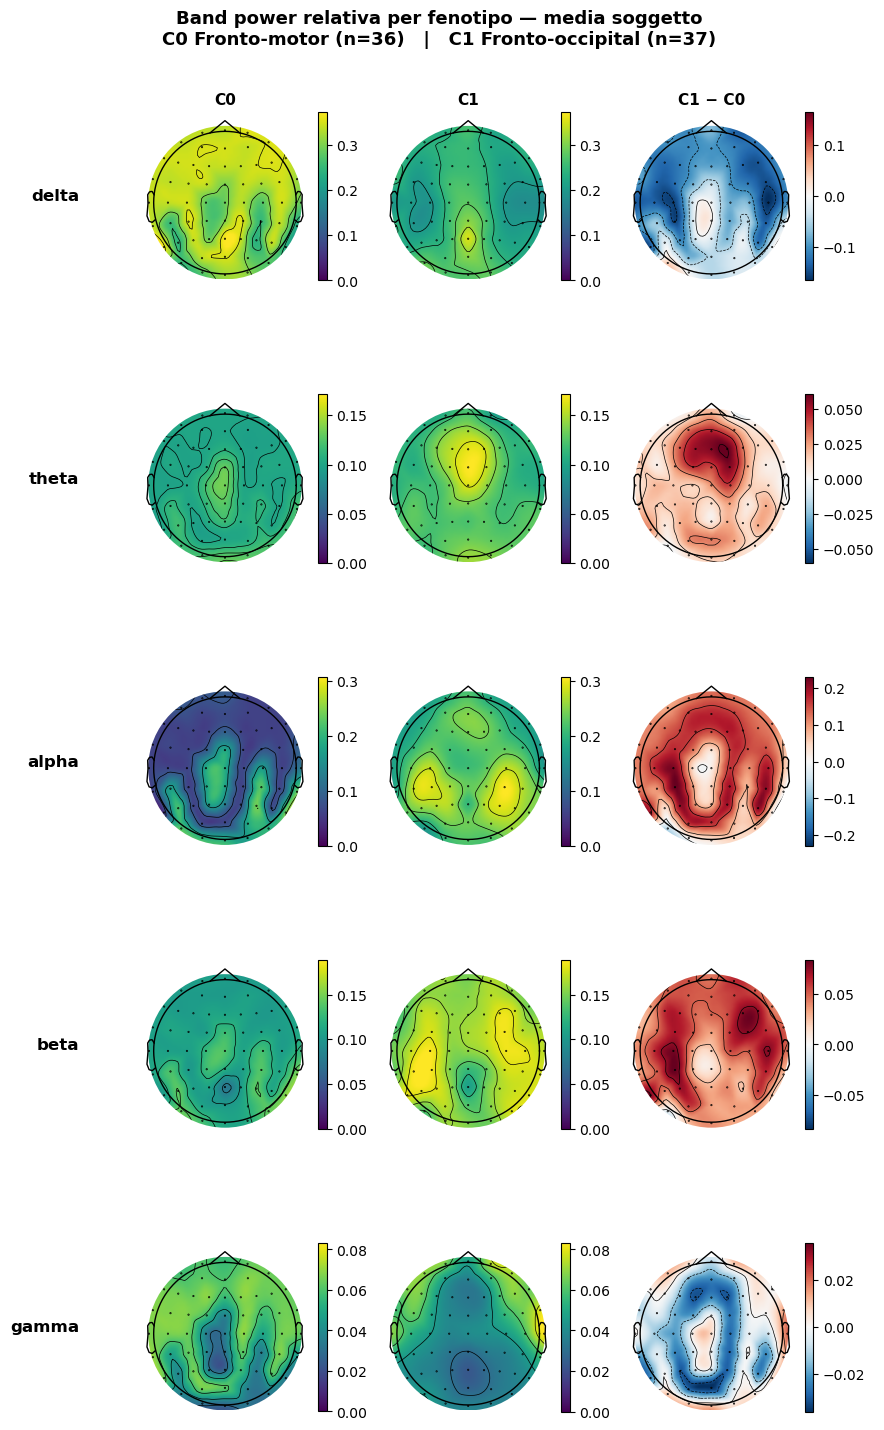

Salvato: eeg40_bandpower_topomaps.png


In [22]:
info_topo = make_topo_info()
fig, axes = plt.subplots(NB, 3, figsize=(9, 3 * NB))
fig.suptitle('Band power relativa per fenotipo — media soggetto\n'
             f'C0 Fronto-motor (n={M0.sum()})   |   C1 Fronto-occipital (n={M1.sum()})',
             fontsize=13, fontweight='bold')
col_titles = ['C0', 'C1', 'C1 \u2212 C0']
for k, band in enumerate(BAND_NAMES):
    vmax = max(POW_C0[k].max(), POW_C1[k].max())
    dmax = np.abs(POW_DIFF[k]).max()
    for j, (vals, cmap, lim) in enumerate([
            (POW_C0[k], 'viridis', (0, vmax)),
            (POW_C1[k], 'viridis', (0, vmax)),
            (POW_DIFF[k], 'RdBu_r', (-dmax, dmax))]):
        ax = axes[k, j]
        im, _ = mne.viz.plot_topomap(vals, info_topo, axes=ax, show=False,
                                     cmap=cmap, vlim=lim, contours=4)
        if k == 0:
            ax.set_title(col_titles[j], fontsize=11, fontweight='bold')
        if j == 0:
            ax.text(-0.35, 0.5, band, transform=ax.transAxes, fontsize=12,
                    fontweight='bold', va='center', ha='right')
        plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg40_bandpower_topomaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: eeg40_bandpower_topomaps.png')

## §6 — Connettività media per banda: |PCC| (ampiezza) e PLV (fase)

Per ciascuna metrica mostriamo la differenza C1−C0 per banda come matrice 61×61, e i top
edge che separano i fenotipi. Attesa: |PCC| separa C0, PLV separa C1.

14:00:04 INFO     |PCC| delta  top edge: AF4-F4(+0.471), F2-F4(+0.454), F2-AFz(+0.448), F1-F2(+0.417), P5-P3(+0.414)
14:00:04 INFO     |PCC| theta  top edge: AF4-F4(+0.580), F2-F4(+0.551), F2-AFz(+0.529), AF4-F2(+0.518), F4-F6(+0.514)
14:00:04 INFO     |PCC| alpha  top edge: AF4-F4(+0.628), F2-F4(+0.621), AF4-F2(+0.613), F4-F6(+0.608), FP2-AF8(+0.588)
14:00:04 INFO     |PCC| beta   top edge: F2-F4(+0.682), P5-P3(+0.674), F4-F6(+0.668), P3-P1(+0.665), CP5-CP3(+0.645)
14:00:04 INFO     |PCC| gamma  top edge: P5-P3(+0.640), F2-F4(+0.619), P3-P1(+0.616), F4-F6(+0.609), CP5-CP3(+0.606)


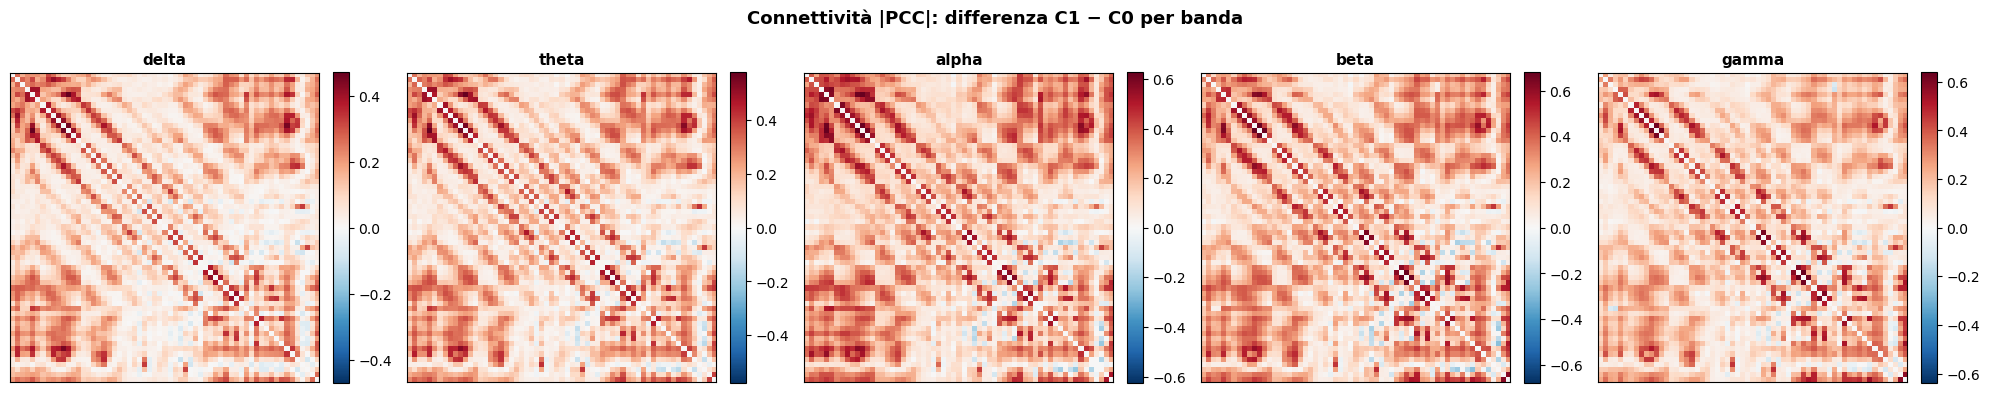

14:00:04 INFO     PLV delta  top edge: AF4-F4(+0.331), F2-AFz(+0.324), F2-F4(+0.312), P4-P6(+0.298), P5-P3(+0.295)
14:00:04 INFO     PLV theta  top edge: AF4-F4(+0.443), F2-AFz(+0.415), F2-F4(+0.413), P5-P3(+0.392), AF3-F3(+0.390)
14:00:04 INFO     PLV alpha  top edge: AF4-F4(+0.510), F2-F4(+0.504), F4-F6(+0.489), AF4-F2(+0.489), F2-AFz(+0.479)
14:00:04 INFO     PLV beta   top edge: P5-P3(+0.577), P3-P1(+0.568), F2-F4(+0.560), F4-F6(+0.549), P4-P6(+0.548)
14:00:04 INFO     PLV gamma  top edge: P5-P3(+0.536), P3-P1(+0.509), P4-P6(+0.508), F4-F6(+0.492), F2-F4(+0.488)


Salvato: eeg40_conn_pcc_diff.png


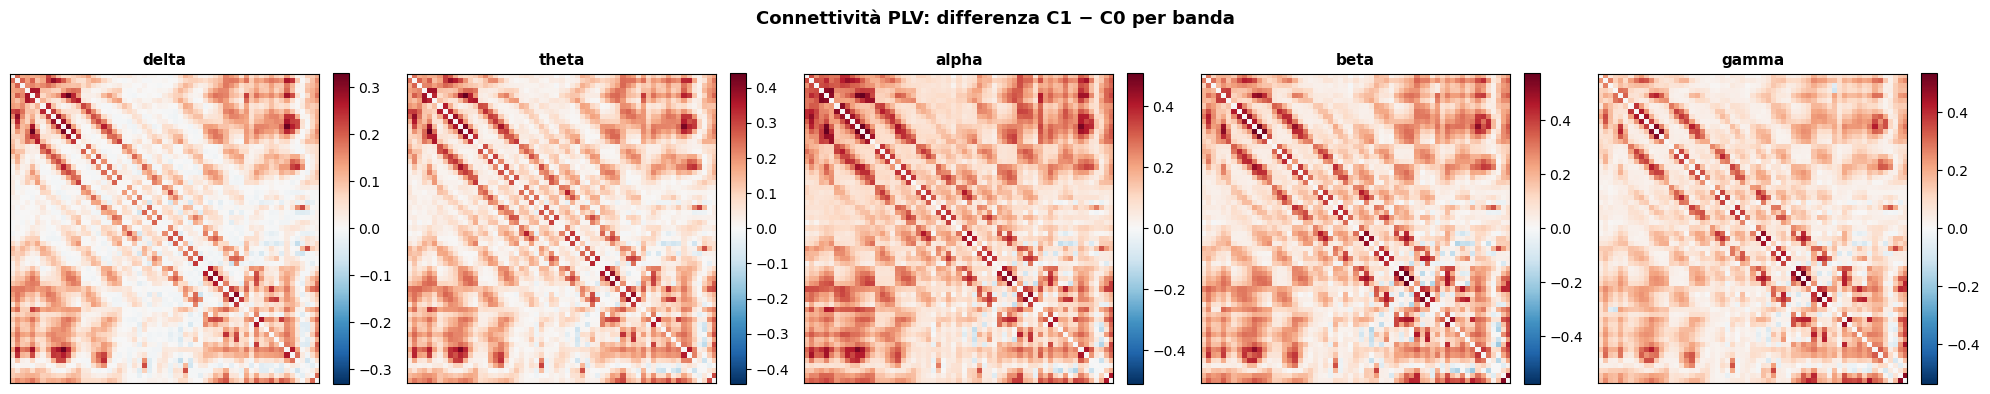

Salvato: eeg40_conn_plv_diff.png


In [23]:
def top_edges(diff_mat, n=8):
    iu = np.triu_indices(N_CHAN, k=1)
    vals = diff_mat[iu]
    order = np.argsort(-np.abs(vals))[:n]
    return [(CHAN_NAMES[iu[0][o]], CHAN_NAMES[iu[1][o]], float(vals[o])) for o in order]

for metric_name, C0m, C1m in [('|PCC|', PCC_C0, PCC_C1), ('PLV', PLV_C0, PLV_C1)]:
    fig, axes = plt.subplots(1, NB, figsize=(4 * NB, 4.2))
    fig.suptitle(f'Connettività {metric_name}: differenza C1 \u2212 C0 per banda',
                 fontsize=13, fontweight='bold')
    for k, band in enumerate(BAND_NAMES):
        diff = C1m[k] - C0m[k]
        dmax = np.abs(diff).max() + 1e-9
        ax = axes[k]
        im = ax.imshow(diff, cmap='RdBu_r', vmin=-dmax, vmax=dmax)
        ax.set_title(f'{band}', fontsize=11, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        edges = top_edges(diff, n=5)
        log.info(f'{metric_name} {band:6s} top edge: ' +
                 ', '.join(f'{a}-{b}({v:+.3f})' for a, b, v in edges))
    plt.tight_layout()
    stem = 'pcc' if metric_name == '|PCC|' else 'plv'
    plt.savefig(FIG_DIR / f'eeg40_conn_{stem}_diff.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Salvato: eeg40_conn_{stem}_diff.png')

## §7 — Effect size: quale banda/metrica separa di più i fenotipi?

Per ogni banda riassumiamo la magnitudine della separazione C0 vs C1 (Cohen's d mediano
sui canali per la power; |d| medio sugli edge per la connettività). *Effect size, non p-value.*

 band  pow_d_med  pow_d_max  pcc_d_mean  pcc_d_max  plv_d_mean  plv_d_max
delta      1.411      3.190       1.824      5.955       1.382      5.309
theta      0.576      1.626       2.132      6.283       1.896      5.786
alpha      1.274      1.932       2.006      5.929       1.910      5.393
 beta      1.035      1.506       2.241      6.216       2.142      5.509
gamma      0.327      2.864       1.947      5.791       1.867      4.977


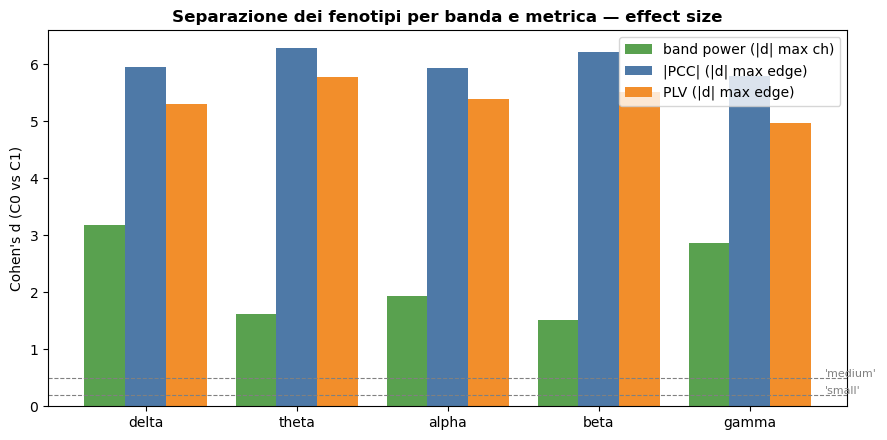

Salvato: eeg40_effectsize_bars.png


In [24]:
def edge_d(arr, k):
    """Cohen's d per edge (triu) fra C0 e C1 per banda k, poi |d| medio."""
    iu = np.triu_indices(N_CHAN, k=1)
    a = arr[M0][:, k][:, iu[0], iu[1]]   # (n0, n_edge)
    b = arr[M1][:, k][:, iu[0], iu[1]]   # (n1, n_edge)
    d = cohens_d(a, b, axis=0)
    return np.abs(d).mean(), np.abs(d).max()

rows = []
for k, band in enumerate(BAND_NAMES):
    pow_d = np.abs(D_POW[k])
    pcc_m, pcc_mx = edge_d(PCC, k)
    plv_m, plv_mx = edge_d(PLV, k)
    rows.append((band, np.median(pow_d), pow_d.max(), pcc_m, pcc_mx, plv_m, plv_mx))

summary = pd.DataFrame(rows, columns=['band', 'pow_d_med', 'pow_d_max',
                                      'pcc_d_mean', 'pcc_d_max', 'plv_d_mean', 'plv_d_max'])
summary.to_csv(FIG_DIR / 'eeg40_effectsize_summary.csv', index=False)
print(summary.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
xp = np.arange(NB); w = 0.27
ax.bar(xp - w, summary['pow_d_max'],  w, label='band power (|d| max ch)',  color='#59a14f')
ax.bar(xp,     summary['pcc_d_max'],  w, label='|PCC| (|d| max edge)',     color='#4e79a7')
ax.bar(xp + w, summary['plv_d_max'],  w, label='PLV (|d| max edge)',       color='#f28e2b')
ax.axhline(0.2, ls='--', c='gray', lw=0.8); ax.axhline(0.5, ls='--', c='gray', lw=0.8)
ax.text(NB - 0.5, 0.21, "'small'", fontsize=8, color='gray')
ax.text(NB - 0.5, 0.51, "'medium'", fontsize=8, color='gray')
ax.set_xticks(xp); ax.set_xticklabels(BAND_NAMES)
ax.set_ylabel("Cohen's d (C0 vs C1)"); ax.legend()
ax.set_title('Separazione dei fenotipi per banda e metrica — effect size', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg40_effectsize_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: eeg40_effectsize_bars.png')

## §8 — Figura riassuntiva per tesi §6.5 + slide *mechanisms*

Una figura pulita: per ciascun fenotipo, la topomap della banda più caratterizzante
(scelta automaticamente dal max |d| in §7) affiancata alla sua firma di connettività.

14:00:06 INFO     Banda più discriminante — power: delta | PLV: theta


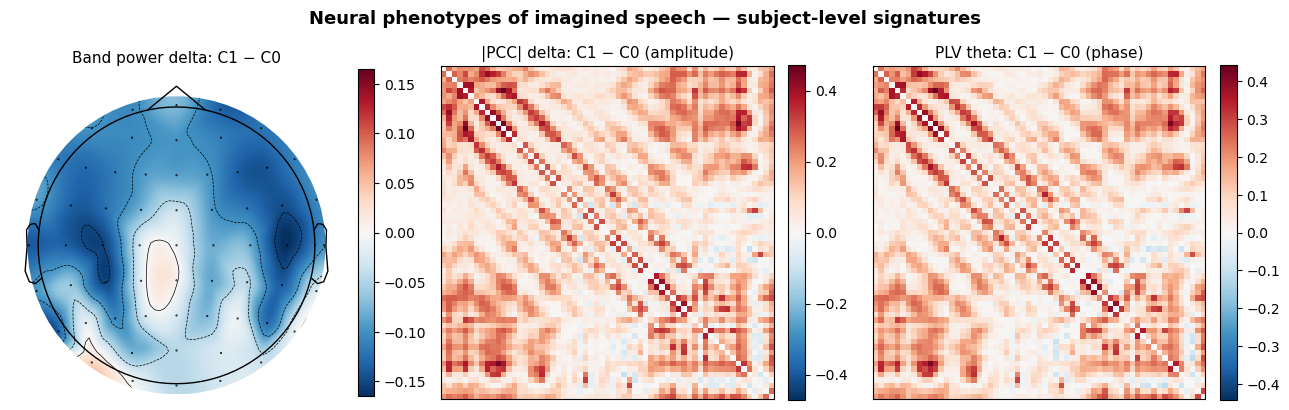

Salvato: eeg40_phenotype_summary.png


In [25]:
# Banda con la maggiore separazione in power e in PLV
band_pow = BAND_NAMES[int(np.argmax(summary['pow_d_max']))]
band_plv = BAND_NAMES[int(np.argmax(summary['plv_d_max']))]
kpow = BAND_NAMES.index(band_pow); kplv = BAND_NAMES.index(band_plv)
log.info(f'Banda più discriminante — power: {band_pow} | PLV: {band_plv}')

info_topo = make_topo_info()
fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
fig.suptitle('Neural phenotypes of imagined speech — subject-level signatures',
             fontsize=13, fontweight='bold')

# (a) differenza band power nella banda più discriminante
dmax = np.abs(POW_DIFF[kpow]).max()
im, _ = mne.viz.plot_topomap(POW_DIFF[kpow], info_topo, axes=axes[0], show=False,
                             cmap='RdBu_r', vlim=(-dmax, dmax), contours=4)
axes[0].set_title(f'Band power {band_pow}: C1 \u2212 C0', fontsize=11)
plt.colorbar(im, ax=axes[0], fraction=0.045, pad=0.04)

# (b) |PCC| diff nella banda power
dpcc = PCC_C1[kpow] - PCC_C0[kpow]; m = np.abs(dpcc).max()
im2 = axes[1].imshow(dpcc, cmap='RdBu_r', vmin=-m, vmax=m)
axes[1].set_title(f'|PCC| {band_pow}: C1 \u2212 C0 (amplitude)', fontsize=11)
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

# (c) PLV diff nella banda fase
dplv = PLV_C1[kplv] - PLV_C0[kplv]; m = np.abs(dplv).max()
im3 = axes[2].imshow(dplv, cmap='RdBu_r', vmin=-m, vmax=m)
axes[2].set_title(f'PLV {band_plv}: C1 \u2212 C0 (phase)', fontsize=11)
axes[2].set_xticks([]); axes[2].set_yticks([])
plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg40_phenotype_summary.png', dpi=160, bbox_inches='tight')
plt.show()
print('Salvato: eeg40_phenotype_summary.png')

## §9 — Export risultati

Salva le medie per cluster e la tabella effect-size per la tesi (§6.5) e per il pptx storico.

In [26]:
OUT = CKPT_DIR / 'cluster_band_profiles.npz'
np.savez_compressed(OUT,
                    pow_c0=POW_C0, pow_c1=POW_C1, pow_diff=POW_DIFF,
                    pcc_c0=PCC_C0, pcc_c1=PCC_C1,
                    plv_c0=PLV_C0, plv_c1=PLV_C1,
                    d_pow=D_POW,
                    bands=np.array(BAND_NAMES), chan_names=np.array(CHAN_NAMES),
                    n_c0=int(M0.sum()), n_c1=int(M1.sum()))
print(f'Salvato: {OUT}')
print('\nFigure prodotte in figures/:')
for f in ['eeg40_bandpower_topomaps', 'eeg40_conn_pcc_diff', 'eeg40_conn_plv_diff',
          'eeg40_effectsize_bars', 'eeg40_phenotype_summary']:
    print(f'  - {f}.png')
print('  - eeg40_effectsize_summary.csv')

Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/models/eeg40/cluster_band_profiles.npz

Figure prodotte in figures/:
  - eeg40_bandpower_topomaps.png
  - eeg40_conn_pcc_diff.png
  - eeg40_conn_plv_diff.png
  - eeg40_effectsize_bars.png
  - eeg40_phenotype_summary.png
  - eeg40_effectsize_summary.csv


## §10 — Topomap pulite: differenza di band power C1−C0 (una per banda)

Versione "pretty" per tesi/slide. Scala simmetrica per banda, canali con
|Cohen d|≥0.8 evidenziati, testo in inglese. **Evidenza non circolare**: la
potenza non è stata usata per definire i cluster.


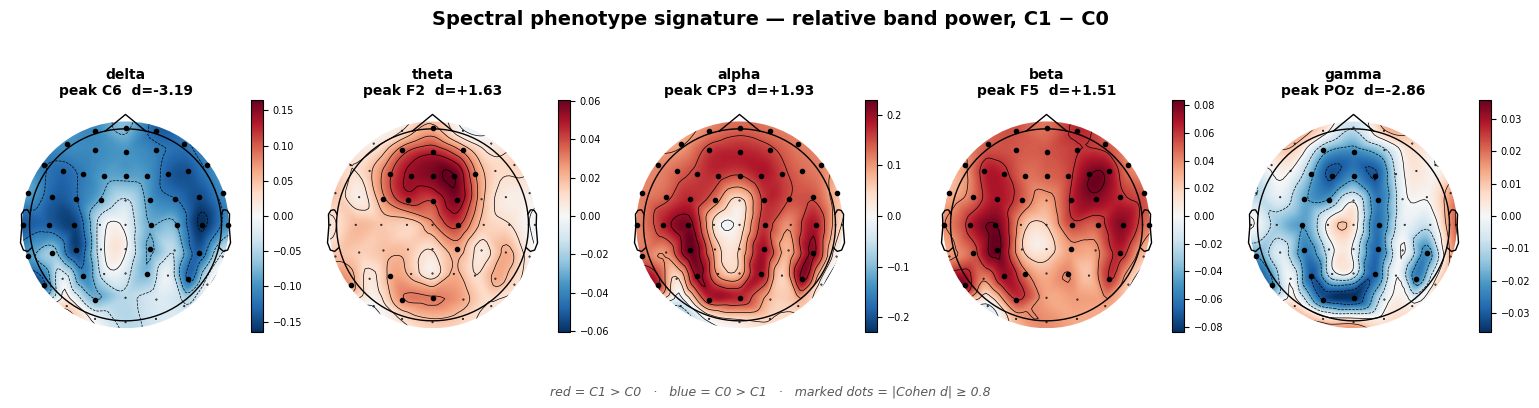

Salvato: eeg40_power_diff_clean.png


In [27]:
# §10 — Topomap PULITE: differenza di band power C1−C0
info_topo = make_topo_info()
fig, axes = plt.subplots(1, NB, figsize=(3.1 * NB, 3.5))
fig.suptitle('Spectral phenotype signature — relative band power, C1 − C0',
             fontsize=14, fontweight='bold', y=1.04)
for k, band in enumerate(BAND_NAMES):
    ax = axes[k]
    vals = POW_DIFF[k]
    dmax = float(np.abs(vals).max()) + 1e-12
    mask = np.abs(D_POW[k]) >= 0.8
    im, _ = mne.viz.plot_topomap(
        vals, info_topo, axes=ax, show=False, cmap='RdBu_r',
        vlim=(-dmax, dmax), contours=6, sensors=True,
        mask=mask, mask_params=dict(marker='o', markerfacecolor='k',
                                    markeredgecolor='k', linewidth=0, markersize=3))
    pk = int(np.argmax(np.abs(D_POW[k])))
    ax.set_title(f'{band}\npeak {CHAN_NAMES[pk]}  d={D_POW[k, pk]:+.2f}',
                 fontsize=10, fontweight='bold')
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(labelsize=7)
fig.text(0.5, -0.06,
         'red = C1 > C0   ·   blue = C0 > C1   ·   marked dots = |Cohen d| ≥ 0.8',
         ha='center', fontsize=9, style='italic', color='0.35')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg40_power_diff_clean.png', dpi=170, bbox_inches='tight')
plt.show()
print('Salvato: eeg40_power_diff_clean.png')


## §11 — Fase: dove differisce il PLV e clustering indipendente (test non circolare)

Due cose:
1. **Topomap del PLV node-strength** (forza di phase-locking di ogni nodo verso
   il resto dello scalpo), differenza C1−C0 per banda → *dove* la fase distingue i fenotipi.
2. **Test pulito**: clustering KMeans *indipendente* sulle feature PLV per banda
   e confronto (ARI) con lo split definito su |PCC|. Se l'ARI è alto, la fase
   porta **genuinamente** la stessa struttura di fenotipo (non circolare: |PCC|
   non entra mai in questo clustering).


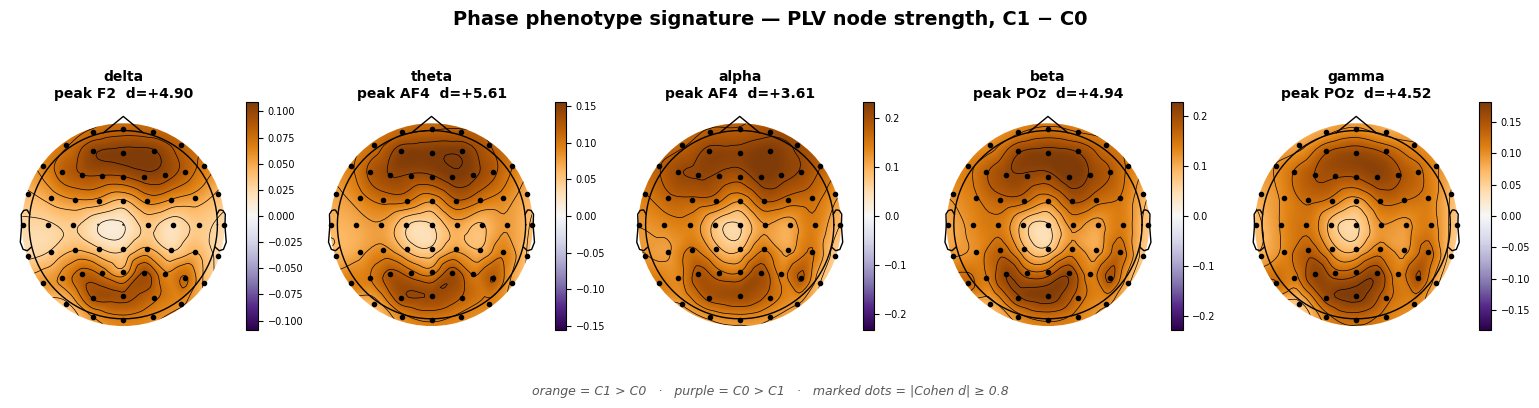

Salvato: eeg40_phase_diff_clean.png

banda     ARI (clustering PLV-only  vs  split |PCC|)
----------------------------------------------------
delta     +0.945
theta     +0.945
alpha     +0.790
beta      +0.945
gamma     +0.945
ALL       +0.945


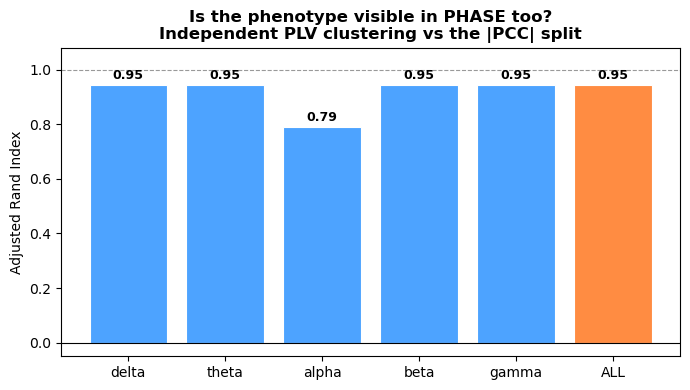

Salvato: eeg40_phase_ari.png


In [28]:
# §11 — FASE: node-strength PLV (C1−C0) + clustering indipendente su PLV → ARI
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# (a) node strength: media del PLV di ogni nodo verso gli altri 60
NS_PLV = PLV.sum(axis=3) / (N_CHAN - 1)                 # (S, NB, 61)
NS_C0, NS_C1 = NS_PLV[M0].mean(0), NS_PLV[M1].mean(0)
NS_DIFF = NS_C1 - NS_C0
D_NS = np.stack([cohens_d(NS_PLV[M0][:, k, :], NS_PLV[M1][:, k, :]) for k in range(NB)])

info_topo = make_topo_info()
fig, axes = plt.subplots(1, NB, figsize=(3.1 * NB, 3.5))
fig.suptitle('Phase phenotype signature — PLV node strength, C1 − C0',
             fontsize=14, fontweight='bold', y=1.04)
for k, band in enumerate(BAND_NAMES):
    ax = axes[k]
    vals = NS_DIFF[k]
    dmax = float(np.abs(vals).max()) + 1e-12
    mask = np.abs(D_NS[k]) >= 0.8
    im, _ = mne.viz.plot_topomap(
        vals, info_topo, axes=ax, show=False, cmap='PuOr_r',
        vlim=(-dmax, dmax), contours=6, sensors=True,
        mask=mask, mask_params=dict(marker='o', markerfacecolor='k',
                                    markeredgecolor='k', linewidth=0, markersize=3))
    pk = int(np.argmax(np.abs(D_NS[k])))
    ax.set_title(f'{band}\npeak {CHAN_NAMES[pk]}  d={D_NS[k, pk]:+.2f}',
                 fontsize=10, fontweight='bold')
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(labelsize=7)
fig.text(0.5, -0.06,
         'orange = C1 > C0   ·   purple = C0 > C1   ·   marked dots = |Cohen d| ≥ 0.8',
         ha='center', fontsize=9, style='italic', color='0.35')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg40_phase_diff_clean.png', dpi=170, bbox_inches='tight')
plt.show()
print('Salvato: eeg40_phase_diff_clean.png')

# (b) Clustering INDIPENDENTE su PLV → ARI con lo split |PCC| (non circolare)
triu = np.triu_indices(N_CHAN, k=1)

def cluster_ari(feat):
    X = StandardScaler().fit_transform(feat)
    Z = PCA(n_components=min(20, feat.shape[0] - 1),
            random_state=RANDOM_SEED).fit_transform(X)
    lab = KMeans(n_clusters=2, n_init=30, random_state=RANDOM_SEED).fit_predict(Z)
    return adjusted_rand_score(LAB, lab)

print(f'\n{"banda":8s}  ARI (clustering PLV-only  vs  split |PCC|)')
print('-' * 52)
ari_band = {}
for k, band in enumerate(BAND_NAMES):
    feat = PLV[:, k][:, triu[0], triu[1]]               # (S, 1830)
    ari_band[band] = cluster_ari(feat)
    print(f'{band:8s}  {ari_band[band]:+.3f}')
feat_all = np.concatenate([PLV[:, k][:, triu[0], triu[1]] for k in range(NB)], axis=1)
ari_all = cluster_ari(feat_all)
print(f'{"ALL":8s}  {ari_all:+.3f}')

# barplot ARI per banda
fig, ax = plt.subplots(figsize=(7, 4))
bands_plot = BAND_NAMES + ['ALL']
vals = [ari_band[b] for b in BAND_NAMES] + [ari_all]
bars = ax.bar(bands_plot, vals, color=['#4DA3FF'] * NB + ['#FF8C42'],
              edgecolor='white', linewidth=0.8)
ax.axhline(0, color='k', lw=0.8)
ax.axhline(1.0, color='0.6', lw=0.8, ls='--')
ax.set_ylabel('Adjusted Rand Index')
ax.set_title('Is the phenotype visible in PHASE too?\n'
             'Independent PLV clustering vs the |PCC| split',
             fontsize=12, fontweight='bold')
ax.set_ylim(min(0.0, min(vals)) - 0.05, 1.08)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f'{v:.2f}',
            ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg40_phase_ari.png', dpi=170, bbox_inches='tight')
plt.show()
print('Salvato: eeg40_phase_ari.png')


## §12 — PSD relativa media per fenotipo: C0 vs C1 (forma spettrale)

Mostra a colpo d'occhio il *tilt*: per ogni soggetto la PSD (media sui 61 canali,
media sui trial img) è normalizzata ad **area = 1**, poi mediata per cluster.
Confronta quindi la **forma** dello spettro, non l'ampiezza assoluta. Il pannello
inferiore (C1 − C0) rende esplicito: centro positivo (C1), estremi negativi (C0).


14:00:09 INFO     PSD cache caricata: (73, 45)


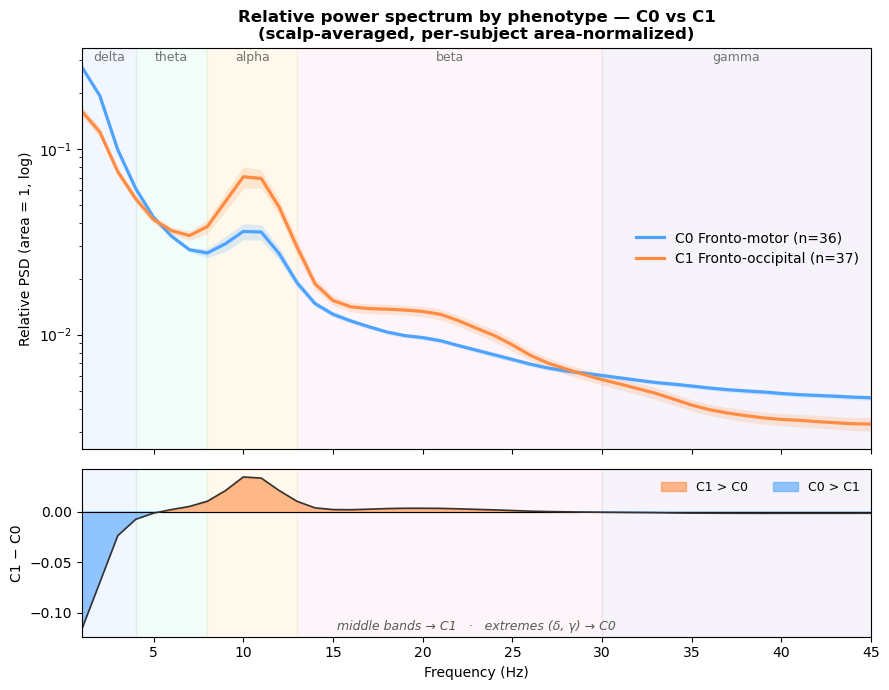

Salvato: eeg40_relpsd_c0_c1.png


In [29]:
# §12 — PSD relativa media: C0 vs C1
from scipy.signal import welch as _welch
PSD_CACHE = CKPT_DIR / 'persubj_relpsd.npz'
FMIN, FMAX = 1.0, 45.0

if PSD_CACHE.exists():
    _p = np.load(PSD_CACHE, allow_pickle=True)
    FREQS = _p['freqs']; RELPSD = _p['relpsd']; SUBJ_P = _p['subjects'].tolist()
    log.info(f'PSD cache caricata: {RELPSD.shape}')
else:
    SUBJ_P = list(SUBJ)
    _f0, _ = _welch(np.zeros((N_CHAN, 384)), fs=FS, nperseg=256, axis=1)
    bsel = (_f0 >= FMIN) & (_f0 <= FMAX)
    FREQS = _f0[bsel]
    RELPSD = np.zeros((len(SUBJ_P), int(bsel.sum())), dtype=np.float32)
    for si, sid in enumerate(tqdm(SUBJ_P, desc='PSD soggetti')):
        acc = np.zeros(int(bsel.sum()), dtype=np.float64); nt = 0
        for p in trials_of[sid]:
            try:
                x = normalize_trial(load_trial(p))
            except Exception:
                continue
            if x.shape[0] != N_CHAN:
                continue
            f, psd = _welch(x, fs=FS, nperseg=min(256, x.shape[1]), axis=1)
            pm = psd.mean(0)[bsel]                                  # media canali
            acc += pm / (np.trapezoid(pm, FREQS) + 1e-12)          # area=1 per trial
            nt += 1
        if nt:
            RELPSD[si] = (acc / nt).astype(np.float32)
    np.savez_compressed(PSD_CACHE, freqs=FREQS, relpsd=RELPSD, subjects=np.array(SUBJ_P))
    log.info(f'Salvato PSD cache: {PSD_CACHE}')

# medie per cluster (+ SEM)
m0 = RELPSD[M0].mean(0); s0 = RELPSD[M0].std(0) / np.sqrt(M0.sum())
m1 = RELPSD[M1].mean(0); s1 = RELPSD[M1].std(0) / np.sqrt(M1.sum())
diff = m1 - m0

BAND_COL = {'delta':'#5B8FF9','theta':'#61DDAA','alpha':'#F6BD16',
            'beta':'#F08BB4','gamma':'#9270CA'}
fig, (axA, axB) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                               gridspec_kw=dict(height_ratios=[2.4, 1]))

# --- pannello A: PSD relativa sovrapposta ---
for name, (lo, hi) in BANDS.items():
    axA.axvspan(lo, hi, color=BAND_COL[name], alpha=0.08)
axA.plot(FREQS, m0, color='#4DA3FF', lw=2.3, label=f'C0 Fronto-motor (n={M0.sum()})')
axA.fill_between(FREQS, m0 - s0, m0 + s0, color='#4DA3FF', alpha=0.18, linewidth=0)
axA.plot(FREQS, m1, color='#FF8C42', lw=2.3, label=f'C1 Fronto-occipital (n={M1.sum()})')
axA.fill_between(FREQS, m1 - s1, m1 + s1, color='#FF8C42', alpha=0.18, linewidth=0)
axA.set_yscale('log')
axA.set_ylabel('Relative PSD (area = 1, log)')
axA.set_title('Relative power spectrum by phenotype — C0 vs C1\n'
              '(scalp-averaged, per-subject area-normalized)', fontweight='bold')
axA.legend(frameon=False)
ytop = axA.get_ylim()[1]
for name, (lo, hi) in BANDS.items():
    axA.text((lo + hi) / 2, ytop * 0.85, name, ha='center', fontsize=9, color='0.45')

# --- pannello B: differenza C1 - C0 ---
for name, (lo, hi) in BANDS.items():
    axB.axvspan(lo, hi, color=BAND_COL[name], alpha=0.08)
axB.axhline(0, color='k', lw=0.8)
axB.fill_between(FREQS, 0, diff, where=(diff > 0), color='#FF8C42', alpha=0.6,
                 interpolate=True, label='C1 > C0')
axB.fill_between(FREQS, 0, diff, where=(diff <= 0), color='#4DA3FF', alpha=0.6,
                 interpolate=True, label='C0 > C1')
axB.plot(FREQS, diff, color='0.2', lw=1.2)
axB.set_xlabel('Frequency (Hz)'); axB.set_ylabel('C1 − C0')
axB.set_xlim(FMIN, FMAX)
axB.legend(frameon=False, ncol=2, fontsize=9)
axB.text(0.5, 0.04, 'middle bands → C1   ·   extremes (δ, γ) → C0',
         transform=axB.transAxes, ha='center', fontsize=9, style='italic', color='0.35')

plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg40_relpsd_c0_c1.png', dpi=170, bbox_inches='tight')
plt.show()
print('Salvato: eeg40_relpsd_c0_c1.png')


## §13 — PSD relativa per OGNI elettrodo (layout topografico): C0 vs C1

Niente scelta di "canali importanti" e niente media globale (che cancella effetti
regionali di segno opposto): **un mini-spettro per ciascuno dei 61 elettrodi**,
disposto alla sua posizione reale sullo scalpo. C0 (blu) vs C1 (arancio), PSD
normalizzata ad area = 1 per canale. Si legge a colpo d'occhio *dove* e *in quale
banda* i due fenotipi divergono.


PSD/ch soggetti:   0%|          | 0/73 [00:00<?, ?it/s]

14:02:48 INFO     Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/models/eeg40/persubj_relpsd_perch.npz


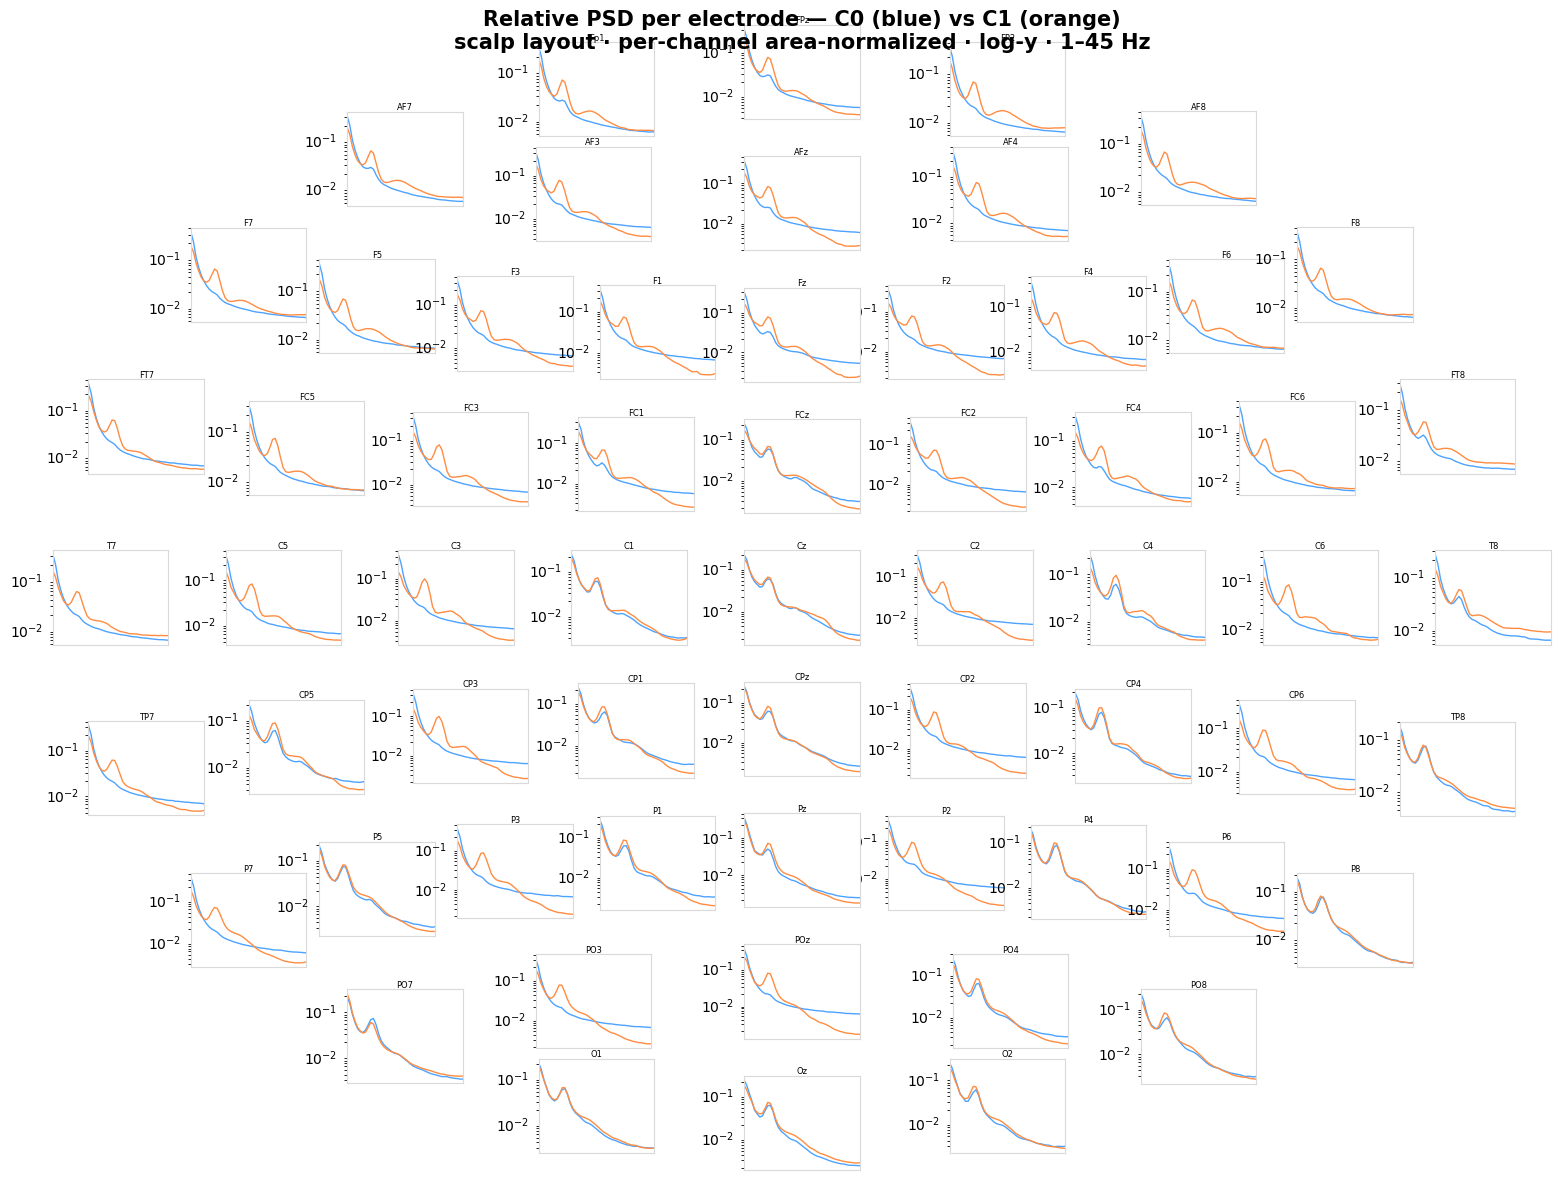

Salvato: eeg40_relpsd_per_channel.png


In [30]:
# §13 — PSD relativa per ogni elettrodo, layout topografico
from scipy.signal import welch as _welch
from mne.viz import iter_topography

PERCH_CACHE = CKPT_DIR / 'persubj_relpsd_perch.npz'
FMIN, FMAX = 1.0, 45.0

if PERCH_CACHE.exists():
    _q = np.load(PERCH_CACHE, allow_pickle=True)
    FREQS = _q['freqs']; RELPSD_CH = _q['relpsd_ch']; SUBJ_Q = _q['subjects'].tolist()
    log.info(f'per-channel PSD cache caricata: {RELPSD_CH.shape}')
else:
    SUBJ_Q = list(SUBJ)
    _f0, _ = _welch(np.zeros((N_CHAN, 384)), fs=FS, nperseg=256, axis=1)
    bsel = (_f0 >= FMIN) & (_f0 <= FMAX); FREQS = _f0[bsel]; nf = int(bsel.sum())
    RELPSD_CH = np.zeros((len(SUBJ_Q), N_CHAN, nf), dtype=np.float32)
    for si, sid in enumerate(tqdm(SUBJ_Q, desc='PSD/ch soggetti')):
        acc = np.zeros((N_CHAN, nf), dtype=np.float64); nt = 0
        for p in trials_of[sid]:
            try:
                x = normalize_trial(load_trial(p))
            except Exception:
                continue
            if x.shape[0] != N_CHAN:
                continue
            f, psd = _welch(x, fs=FS, nperseg=min(256, x.shape[1]), axis=1)
            psd = psd[:, bsel]
            psd = psd / (np.trapezoid(psd, FREQS, axis=1)[:, None] + 1e-12)  # area=1 per canale
            acc += psd; nt += 1
        if nt:
            RELPSD_CH[si] = (acc / nt).astype(np.float32)
    np.savez_compressed(PERCH_CACHE, freqs=FREQS, relpsd_ch=RELPSD_CH,
                        subjects=np.array(SUBJ_Q), chan_names=np.array(CHAN_NAMES))
    log.info(f'Salvato: {PERCH_CACHE}')

mC0 = RELPSD_CH[M0].mean(0)        # (61, nf)
mC1 = RELPSD_CH[M1].mean(0)

info_topo = make_topo_info()
fig = plt.figure(figsize=(15, 12))
fig.suptitle('Relative PSD per electrode — C0 (blue) vs C1 (orange)\n'
             'scalp layout · per-channel area-normalized · log-y · 1–45 Hz',
             fontsize=15, fontweight='bold', y=0.99)

for ax, idx in iter_topography(info_topo, fig=fig,
                               fig_facecolor='white', axis_facecolor='white',
                               axis_spinecolor='0.85'):
    ax.plot(FREQS, mC0[idx], color='#4DA3FF', lw=1.0)
    ax.plot(FREQS, mC1[idx], color='#FF8C42', lw=1.0)
    ax.set_yscale('log')
    ax.set_xlim(FMIN, FMAX)
    ax.set_title(CHAN_NAMES[idx], fontsize=6, pad=0.5)

plt.savefig(FIG_DIR / 'eeg40_relpsd_per_channel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: eeg40_relpsd_per_channel.png')


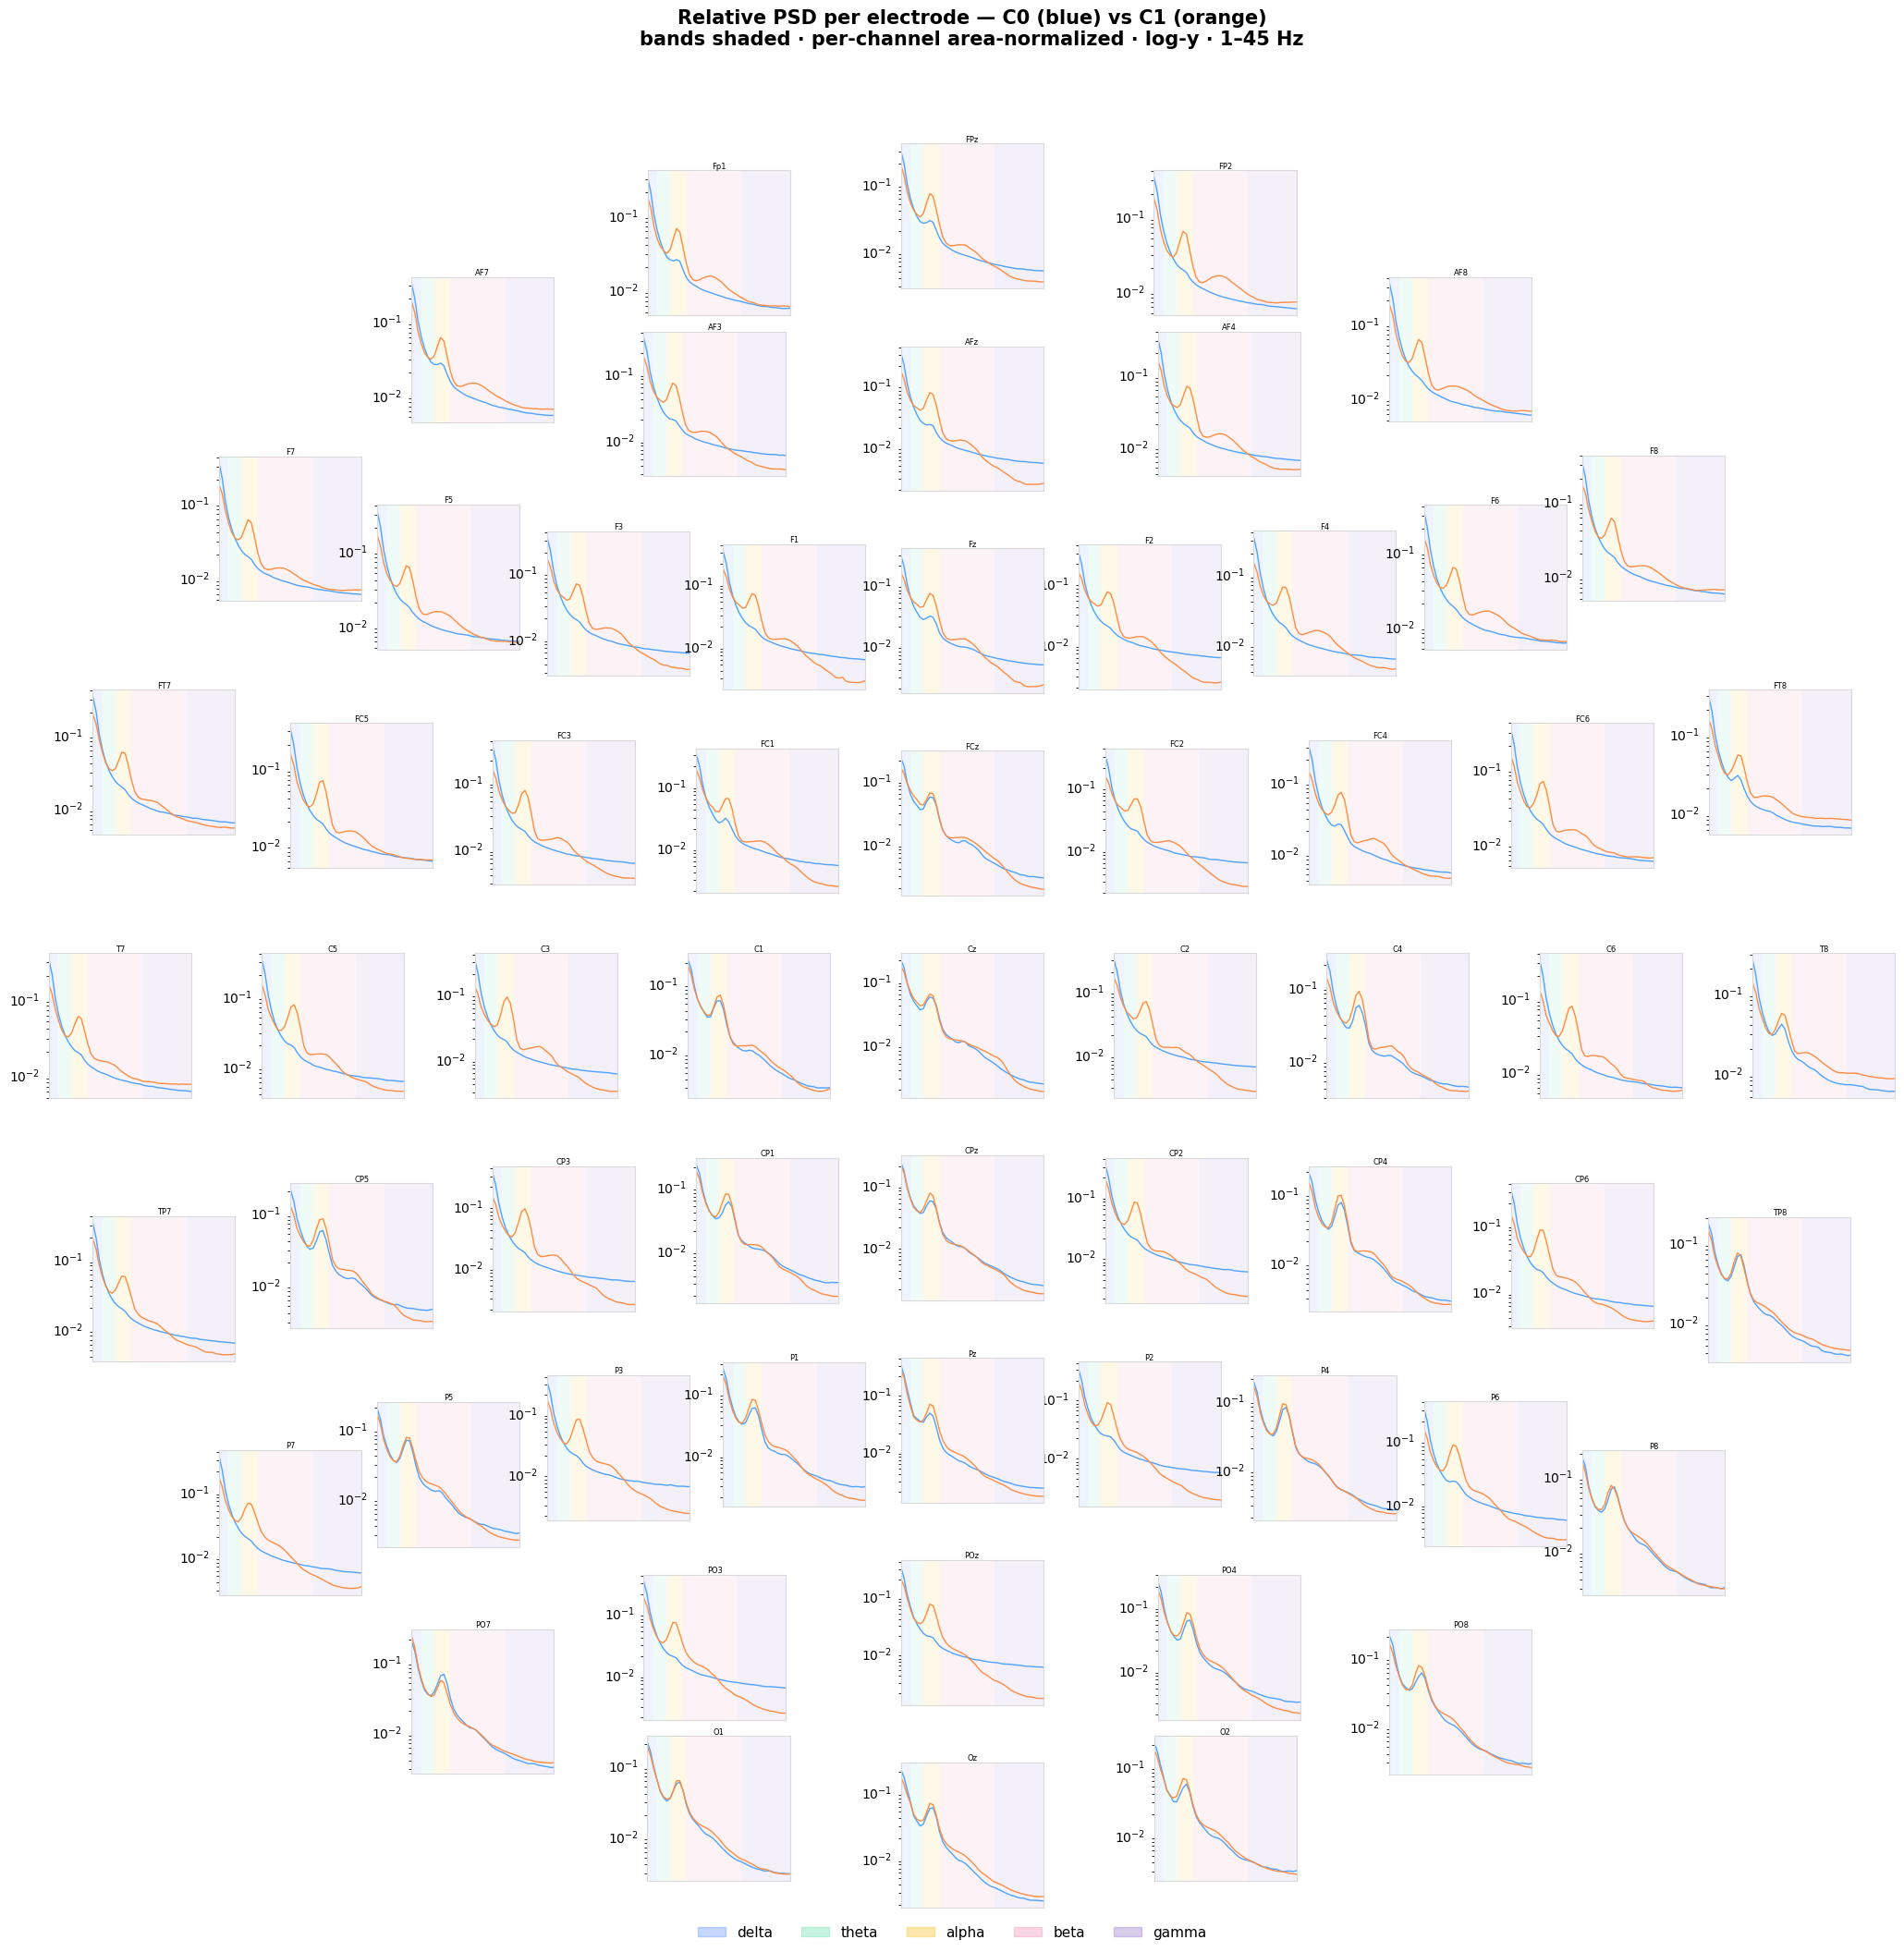

Salvato: eeg40_relpsd_per_channel_bands.png


In [36]:
# §13b — PSD per elettrodo con le 5 bande ombreggiate
from mne.viz import iter_topography
import matplotlib.patches as mpatches

_q = np.load(CKPT_DIR / 'persubj_relpsd_perch.npz', allow_pickle=True)
FREQS = _q['freqs']; RELPSD_CH = _q['relpsd_ch']
mC0 = RELPSD_CH[M0].mean(0); mC1 = RELPSD_CH[M1].mean(0)

BAND_COL = {'delta':'#5B8FF9','theta':'#61DDAA','alpha':'#F6BD16',
            'beta':'#F08BB4','gamma':'#9270CA'}
info_topo = make_topo_info()
fig = plt.figure(figsize=(20, 20))
fig.suptitle('Relative PSD per electrode — C0 (blue) vs C1 (orange)\n'
             'bands shaded · per-channel area-normalized · log-y · 1–45 Hz',
             fontsize=15, fontweight='bold', y=1.05)

for ax, idx in iter_topography(info_topo, fig=fig, fig_facecolor='white',
                               axis_facecolor='white', axis_spinecolor='0.85'):
    for name, (lo, hi) in BANDS.items():
        ax.axvspan(lo, hi, color=BAND_COL[name], alpha=0.10, lw=0)
    ax.plot(FREQS, mC0[idx], color='#4DA3FF', lw=1.0)
    ax.plot(FREQS, mC1[idx], color='#FF8C42', lw=1.0)
    ax.set_yscale('log'); ax.set_xlim(1, 45)
    ax.set_title(CHAN_NAMES[idx], fontsize=6, pad=0.5)

handles = [mpatches.Patch(color=c, alpha=0.35, label=n) for n, c in BAND_COL.items()]
fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False, fontsize=11)
plt.savefig(FIG_DIR / 'eeg40_relpsd_per_channel_bands.png', dpi=150, bbox_inches='tight')
plt.show(); print('Salvato: eeg40_relpsd_per_channel_bands.png')

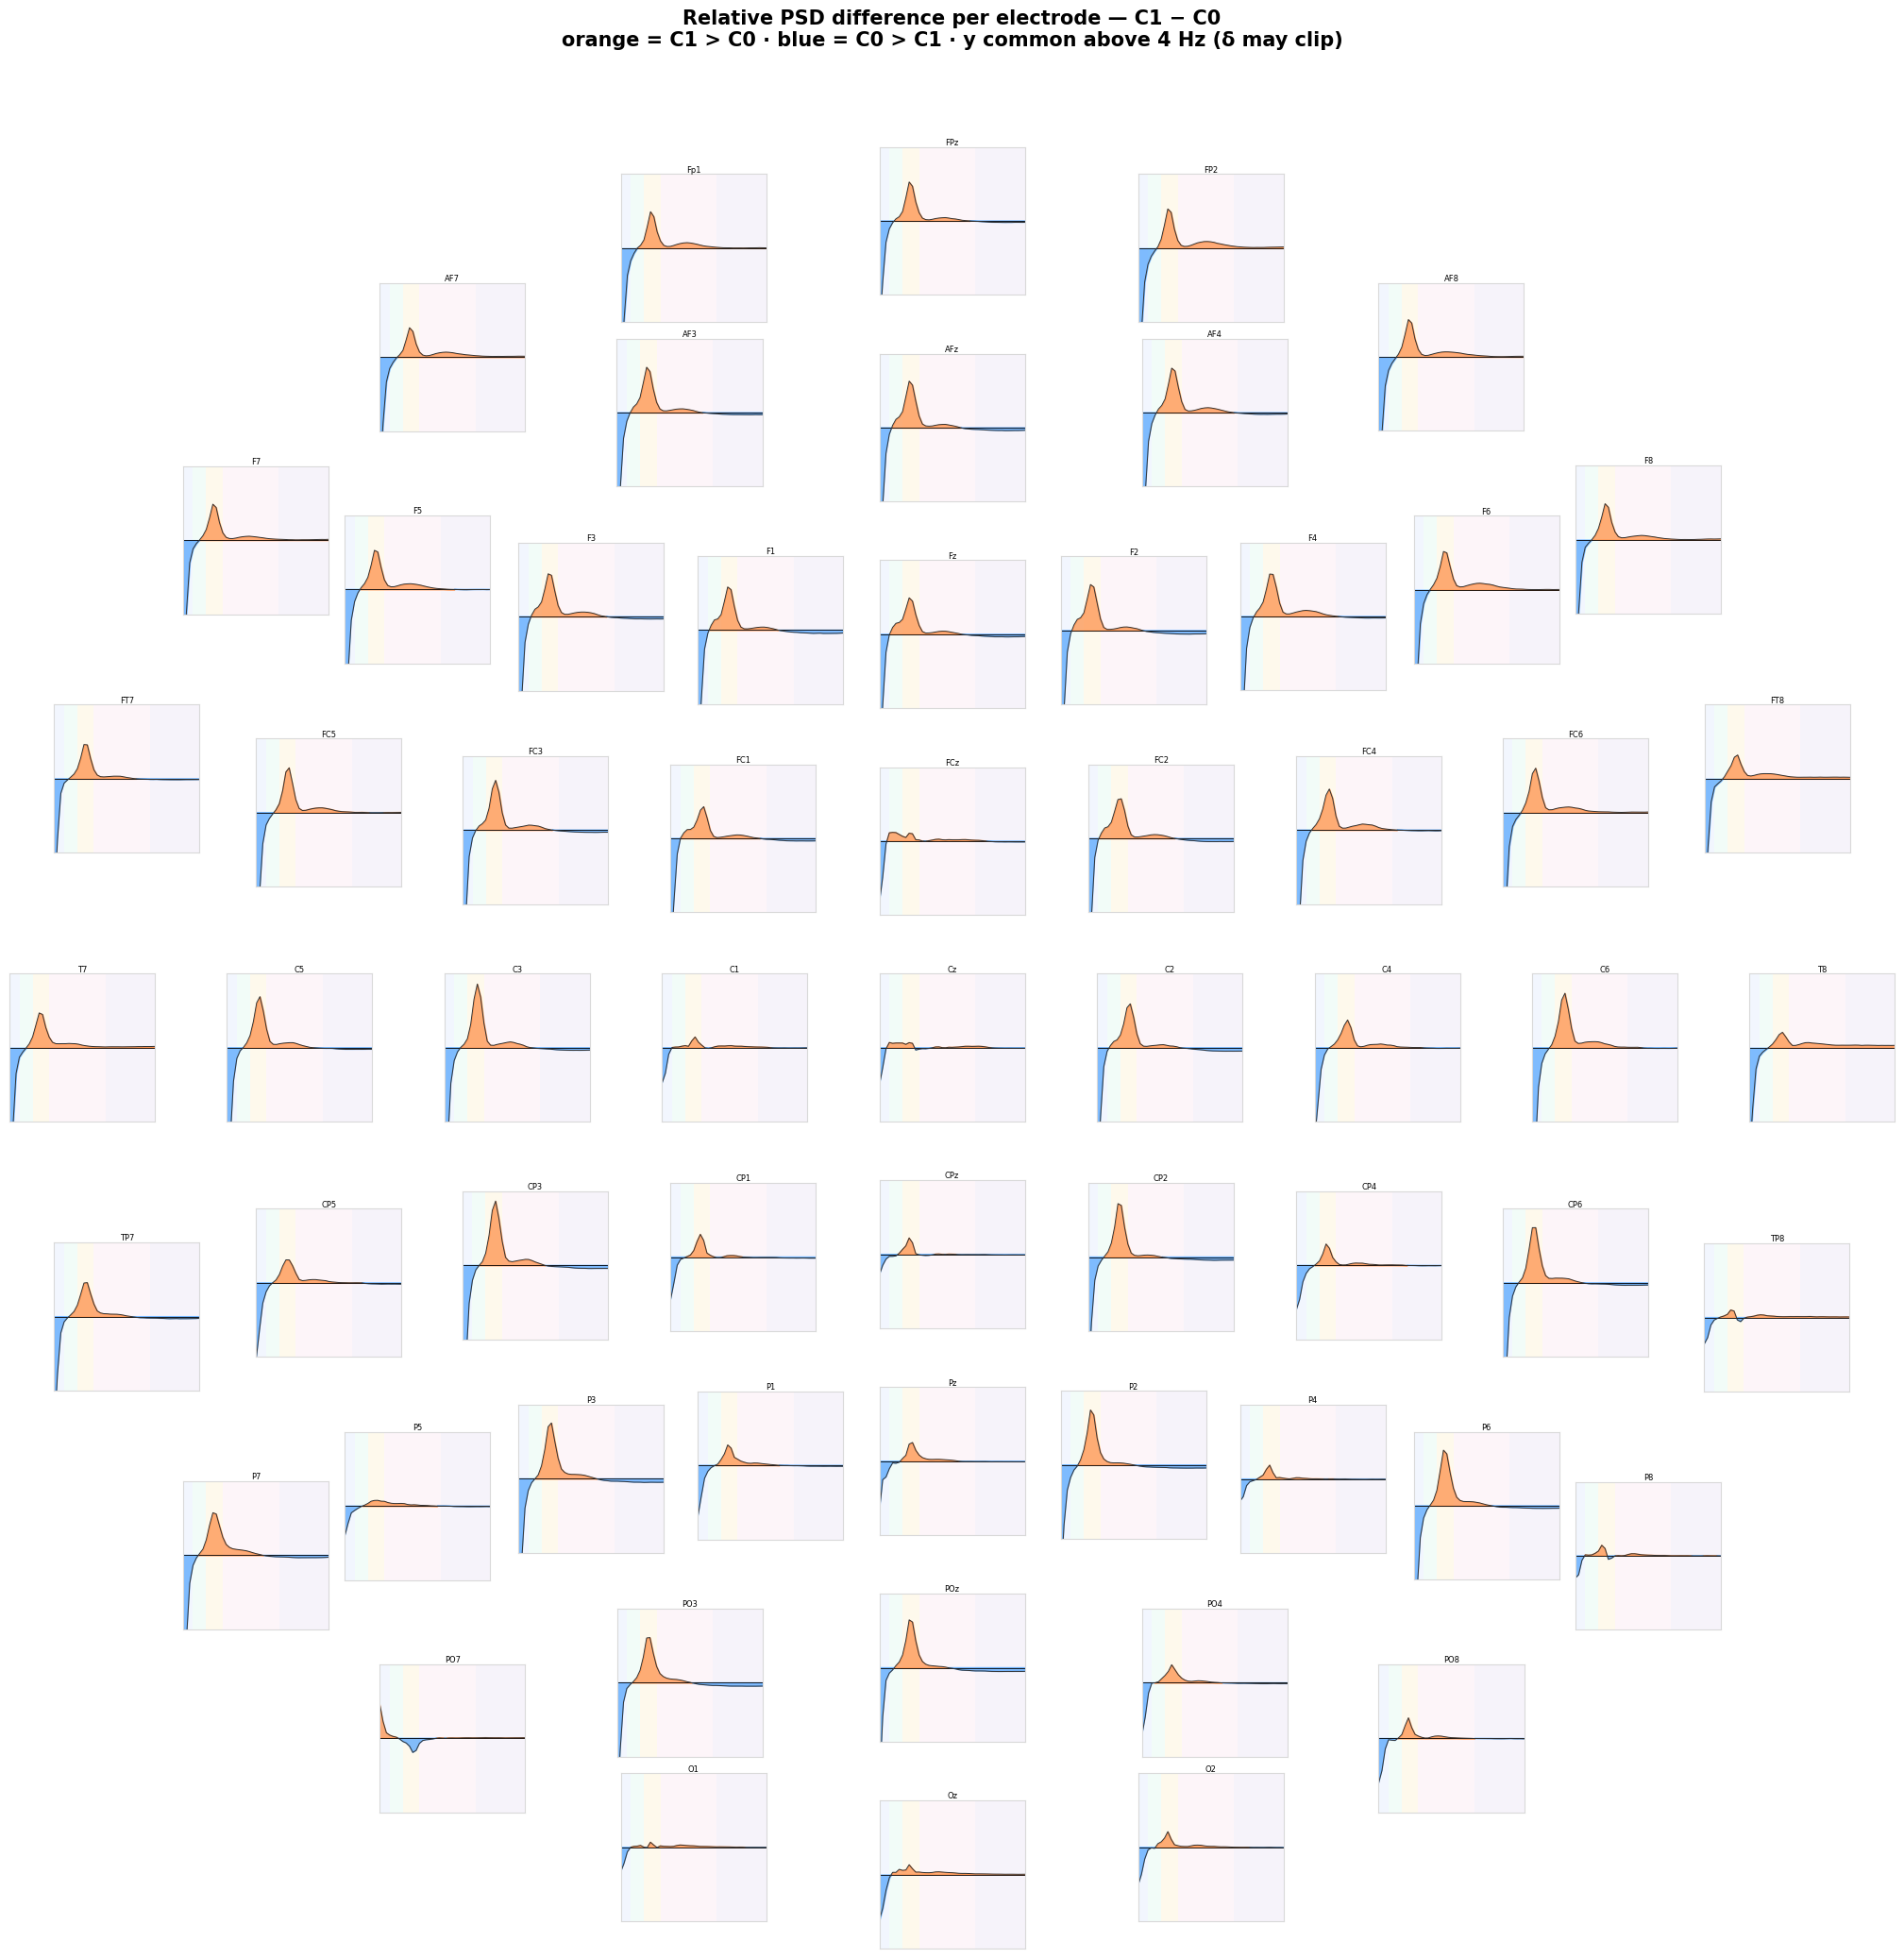

Salvato: eeg40_relpsd_per_channel_diff.png


In [37]:
# §13c — PSD per elettrodo: differenza C1 − C0 (fill per segno)
from mne.viz import iter_topography

_q = np.load(CKPT_DIR / 'persubj_relpsd_perch.npz', allow_pickle=True)
FREQS = _q['freqs']; RELPSD_CH = _q['relpsd_ch']
mC0 = RELPSD_CH[M0].mean(0); mC1 = RELPSD_CH[M1].mean(0)
DIFF = mC1 - mC0                                            # (61, nf)

BAND_COL = {'delta':'#5B8FF9','theta':'#61DDAA','alpha':'#F6BD16',
            'beta':'#F08BB4','gamma':'#9270CA'}
# scala comune sopra i 4 Hz (il delta a 1–2 Hz è enorme e schiaccerebbe l'alpha)
hf = FREQS >= 4
ylim = float(np.abs(DIFF[:, hf]).max()) * 1.15

info_topo = make_topo_info()
fig = plt.figure(figsize=(20, 20))
fig.suptitle('Relative PSD difference per electrode — C1 − C0\n'
             'orange = C1 > C0 · blue = C0 > C1 · y common above 4 Hz (δ may clip)',
             fontsize=15, fontweight='bold', y=1.05)

for ax, idx in iter_topography(info_topo, fig=fig, fig_facecolor='white',
                               axis_facecolor='white', axis_spinecolor='0.85'):
    d = DIFF[idx]
    for name, (lo, hi) in BAND_COL.items() if False else BANDS.items():
        ax.axvspan(lo, hi, color=BAND_COL[name], alpha=0.08, lw=0)
    ax.axhline(0, color='k', lw=0.6)
    ax.fill_between(FREQS, 0, d, where=(d > 0), color='#FF8C42', alpha=0.7, interpolate=True)
    ax.fill_between(FREQS, 0, d, where=(d <= 0), color='#4DA3FF', alpha=0.7, interpolate=True)
    ax.plot(FREQS, d, color='0.2', lw=0.7)
    ax.set_xlim(1, 45); ax.set_ylim(-ylim, ylim)
    ax.set_title(CHAN_NAMES[idx], fontsize=6, pad=0.5)

plt.savefig(FIG_DIR / 'eeg40_relpsd_per_channel_diff.png', dpi=150, bbox_inches='tight')
plt.show(); print('Salvato: eeg40_relpsd_per_channel_diff.png')

zona              alpha C0   alpha C1   Cohen d (C1−C0)
--------------------------------------------------------
Frontal           0.0971    0.2480     +1.52
Fronto-central    0.1159    0.2491     +1.40
Central           0.1435    0.2689     +1.25
Centro-parietal   0.1762    0.2963     +1.06
Parietal          0.1806    0.2936     +0.93
Occipital         0.1980    0.2616     +0.49


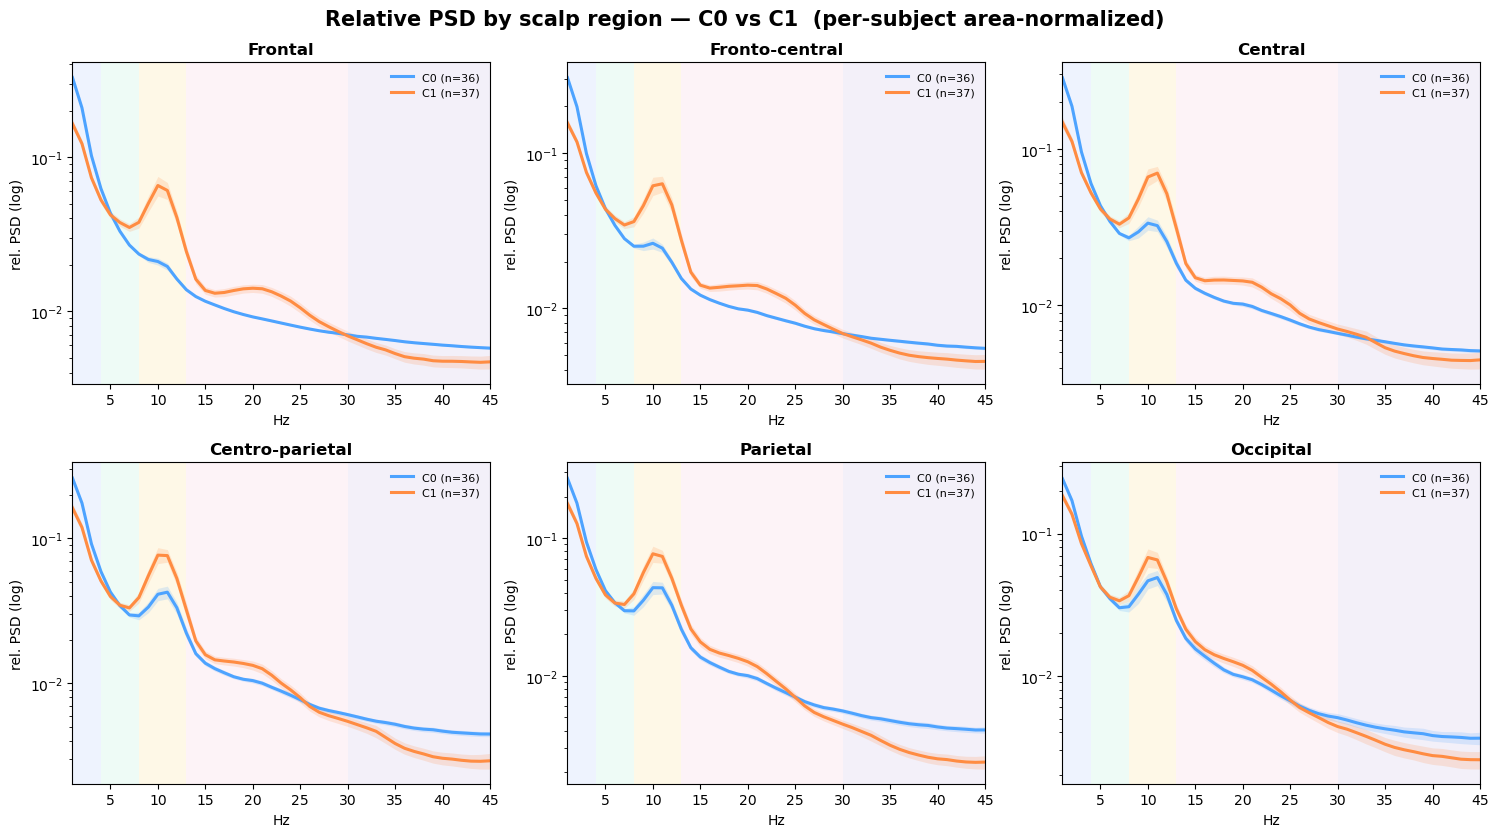

Salvato: eeg40_relpsd_by_region.png


In [38]:
# §13d — PSD media per ZONA dello scalpo: C0 vs C1 (+ Cohen d alpha per zona)
_q = np.load(CKPT_DIR / 'persubj_relpsd_perch.npz', allow_pickle=True)
FREQS = _q['freqs']; RELPSD_CH = _q['relpsd_ch']      # (S, 61, nf)

REGIONS = {
    'Frontal':         ['Fp1','Fp2','AF7','AF3','AFz','AF4','AF8','F7','F5','F3','F1','Fz','F2','F4','F6','F8'],
    'Fronto-central':  ['FT7','FC5','FC3','FC1','FCz','FC2','FC4','FC6','FT8'],
    'Central':         ['T7','C5','C3','C1','Cz','C2','C4','C6','T8'],
    'Centro-parietal': ['TP7','CP5','CP3','CP1','CPz','CP2','CP4','CP6','TP8'],
    'Parietal':        ['P7','P5','P3','P1','Pz','P2','P4','P6','P8'],
    'Occipital':       ['PO7','PO5','PO3','POz','PO4','PO6','PO8','O1','Oz','O2'],
}
REG_IDX = {r: [CHAN_NAMES.index(c) for c in chs if c in CHAN_NAMES]
           for r, chs in REGIONS.items()}

def _cohend(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2) + 1e-12)
    return (b.mean() - a.mean()) / sp

BAND_COL = {'delta':'#5B8FF9','theta':'#61DDAA','alpha':'#F6BD16',
            'beta':'#F08BB4','gamma':'#9270CA'}
alpha_sel = (FREQS >= 8) & (FREQS <= 13)

fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
fig.suptitle('Relative PSD by scalp region — C0 vs C1  (per-subject area-normalized)',
             fontsize=15, fontweight='bold')
print(f'{"zona":16s}  alpha C0   alpha C1   Cohen d (C1−C0)')
print('-'*56)
for ax, (reg, idx) in zip(axes.ravel(), REG_IDX.items()):
    reg_psd = RELPSD_CH[:, idx, :].mean(1)               # (S, nf) media canali zona
    c0, c1 = reg_psd[M0], reg_psd[M1]
    m0, s0 = c0.mean(0), c0.std(0)/np.sqrt(M0.sum())
    m1, s1 = c1.mean(0), c1.std(0)/np.sqrt(M1.sum())
    for name, (lo, hi) in BANDS.items():
        ax.axvspan(lo, hi, color=BAND_COL[name], alpha=0.10, lw=0)
    ax.plot(FREQS, m0, color='#4DA3FF', lw=2.2, label=f'C0 (n={M0.sum()})')
    ax.fill_between(FREQS, m0-s0, m0+s0, color='#4DA3FF', alpha=0.18, lw=0)
    ax.plot(FREQS, m1, color='#FF8C42', lw=2.2, label=f'C1 (n={M1.sum()})')
    ax.fill_between(FREQS, m1-s1, m1+s1, color='#FF8C42', alpha=0.18, lw=0)
    ax.set_yscale('log'); ax.set_xlim(1, 45)
    ax.set_title(reg, fontsize=12, fontweight='bold')
    ax.set_xlabel('Hz'); ax.set_ylabel('rel. PSD (log)')
    ax.legend(frameon=False, fontsize=8)
    a0 = np.trapezoid(c0[:, alpha_sel], FREQS[alpha_sel], axis=1)
    a1 = np.trapezoid(c1[:, alpha_sel], FREQS[alpha_sel], axis=1)
    print(f'{reg:16s}  {a0.mean():.4f}    {a1.mean():.4f}     {_cohend(a0, a1):+.2f}')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg40_relpsd_by_region.png', dpi=160, bbox_inches='tight')
plt.show(); print('Salvato: eeg40_relpsd_by_region.png')

## §14 — Discriminatore a livello soggetto: alpha relativo fronto-centrale + AUC

Quanto pulita è la separazione sul *singolo soggetto* (non solo sulle medie di cluster).
Marker = potenza alpha relativa media sul blocco fronto-centrale. Strip+box C0 vs C1,
ROC e AUC, soglia di Youden, Mann–Whitney.


In [ ]:
# §14 — Discriminatore single-subject: alpha fronto-centrale
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import mannwhitneyu

ALPHA = BAND_NAMES.index('alpha')
FRONTAL = ['Fp1','Fp2','AF7','AF3','AFz','AF4','AF8','F7','F5','F3','F1','Fz','F2','F4','F6','F8',
           'FT7','FC5','FC3','FC1','FCz','FC2','FC4','FC6','FT8']
fidx = [CHAN_NAMES.index(c) for c in FRONTAL if c in CHAN_NAMES]
marker = POW[:, ALPHA, fidx].mean(1)                 # (S,) alpha rel fronto-centrale
m0v, m1v = marker[M0], marker[M1]

auc = roc_auc_score(LAB, marker)
if auc < 0.5:
    auc = 1.0 - auc
U, pval = mannwhitneyu(m1v, m0v)
fpr, tpr, thr = roc_curve(LAB, marker)
thr_opt = thr[np.argmax(tpr - fpr)]

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11, 4.6),
                               gridspec_kw=dict(width_ratios=[1.4, 1]))
rng = np.random.default_rng(0)
for i, (vals, col) in enumerate([(m0v, '#4DA3FF'), (m1v, '#FF8C42')]):
    x = i + (rng.random(len(vals)) - 0.5) * 0.22
    axA.scatter(x, vals, color=col, alpha=0.85, s=42, edgecolor='white', linewidth=0.5, zorder=3)
    bp = axA.boxplot(vals, positions=[i], widths=0.5, showfliers=False,
                     medianprops=dict(color=col, lw=2.2))
axA.axhline(thr_opt, color='0.5', ls='--', lw=1)
axA.text(1.48, thr_opt, f' Youden thr = {thr_opt:.3f}', color='0.4', fontsize=8, va='bottom', ha='right')
axA.set_xticks([0, 1]); axA.set_xticklabels([f'C0 (n={M0.sum()})', f'C1 (n={M1.sum()})'])
axA.set_ylabel('Fronto-central relative alpha power')
axA.set_title(f'Single-subject discriminator\nMann–Whitney p = {pval:.1e}', fontweight='bold')
axB.plot(fpr, tpr, color='#FF8C42', lw=2.4)
axB.plot([0, 1], [0, 1], color='0.6', ls='--', lw=1)
axB.set_xlabel('False positive rate'); axB.set_ylabel('True positive rate')
axB.set_title(f'ROC — AUC = {auc:.3f}', fontweight='bold')
axB.set_xlim(0, 1); axB.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg40_alpha_discriminator.png', dpi=170, bbox_inches='tight')
plt.show()
print(f'AUC={auc:.3f}  Mann-Whitney p={pval:.2e}  Youden thr={thr_opt:.3f}')
print(f'alpha frontale  C0={m0v.mean():.4f}±{m0v.std():.4f}   C1={m1v.mean():.4f}±{m1v.std():.4f}')


## §15 — Gradiente antero-posteriore dell'alpha: C0 vs C1

L'alpha relativo medio per zona, ordinate fronte → occipite. Rende esplicito che
l'alpha di C1 è anteriorizzato e che le due curve convergono posteriormente.


In [ ]:
# §15 — Gradiente antero-posteriore dell'alpha
ALPHA = BAND_NAMES.index('alpha')
REGIONS_AP = {
    'Frontal':         ['Fp1','Fp2','AF7','AF3','AFz','AF4','AF8','F7','F5','F3','F1','Fz','F2','F4','F6','F8'],
    'Fronto-central':  ['FT7','FC5','FC3','FC1','FCz','FC2','FC4','FC6','FT8'],
    'Central':         ['T7','C5','C3','C1','Cz','C2','C4','C6','T8'],
    'Centro-parietal': ['TP7','CP5','CP3','CP1','CPz','CP2','CP4','CP6','TP8'],
    'Parietal':        ['P7','P5','P3','P1','Pz','P2','P4','P6','P8'],
    'Occipital':       ['PO7','PO5','PO3','POz','PO4','PO6','PO8','O1','Oz','O2'],
}
labels = list(REGIONS_AP); x = np.arange(len(labels))

def reg_alpha(mask):
    mm, ss = [], []
    for chs in REGIONS_AP.values():
        idx = [CHAN_NAMES.index(c) for c in chs if c in CHAN_NAMES]
        v = POW[mask][:, ALPHA, idx].mean(1)
        mm.append(v.mean()); ss.append(v.std() / np.sqrt(mask.sum()))
    return np.array(mm), np.array(ss)

m0, s0 = reg_alpha(M0); m1, s1 = reg_alpha(M1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(x, m0, s0, color='#4DA3FF', lw=2.4, marker='o', capsize=3, label=f'C0 (n={M0.sum()})')
ax.errorbar(x, m1, s1, color='#FF8C42', lw=2.4, marker='o', capsize=3, label=f'C1 (n={M1.sum()})')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Relative alpha power'); ax.set_xlabel('Antero-posterior axis')
ax.set_title('Antero-posterior alpha gradient — C0 vs C1\n'
             'C1 alpha-dominant everywhere; gap largest fronto-centrally, persists posteriorly', fontweight='bold')
ax.legend(frameon=False); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg40_alpha_ap_gradient.png', dpi=170, bbox_inches='tight')
plt.show()
print('Salvato: eeg40_alpha_ap_gradient.png')


## §16 — Elettrodi che definiscono il fenotipo (alpha)

"Significativo" non è la lente giusta qui: con 73 soggetti e stime stabili,
**45/61 elettrodi** superano permutation+FDR, **tutti** nella stessa direzione
(C1>C0) → la dominanza alpha di C1 è **globale e unidirezionale** (nessun
elettrodo C0-defining). Per *localizzare* il fenotipo si usa l'**effect size**:
topomap continua del Cohen's d (C1−C0) con marcati i **top-12 elettrodi per |d|**
(dove l'effetto si concentra — fronto-centrale).


In [ ]:
# §16 — Elettrodi che definiscono i fenotipi (alpha): effect size + significatività
ALPHA = BAND_NAMES.index('alpha')
a = POW[:, ALPHA, :]                       # (S, 61) alpha relativo per canale
d_obs = cohens_d(a[M0], a[M1])             # (61,) C1 - C0

# significatività (permutation + FDR) — solo per riportare l'unidirezionalità
rng = np.random.default_rng(42)
NPERM = 5000; n0 = int(M0.sum()); idx_all = np.arange(len(LAB))
null = np.empty((NPERM, N_CHAN), dtype=np.float32)
for i in range(NPERM):
    perm = rng.permutation(idx_all)
    null[i] = cohens_d(a[perm[:n0]], a[perm[n0:]])
p = (np.abs(null) >= np.abs(d_obs)).mean(0)
def bh_adjust(pv):
    pv = np.asarray(pv, float); n = len(pv); order = np.argsort(pv)
    adj_sorted = np.minimum.accumulate((pv[order] * n / np.arange(1, n + 1))[::-1])[::-1]
    adj = np.empty(n); adj[order] = np.clip(adj_sorted, 0, 1); return adj
sig = bh_adjust(p) < 0.05

# marcatura per EFFECT SIZE (dove l'effetto si concentra), non per significatività:
# top-12 elettrodi per |Cohen d|
TOPN = 12
order_all = np.argsort(-np.abs(d_obs))
core = np.zeros(N_CHAN, dtype=bool); core[order_all[:TOPN]] = True

info_topo = make_topo_info()
fig, ax = plt.subplots(figsize=(6.6, 6))
dmax = float(np.abs(d_obs).max())
im, _ = mne.viz.plot_topomap(
    d_obs, info_topo, axes=ax, show=False, cmap='RdBu_r', vlim=(-dmax, dmax),
    contours=6, sensors=True,
    mask=core, mask_params=dict(marker='o', markerfacecolor='k',
                                markeredgecolor='k', markersize=8, linewidth=0))
ax.set_title('Where the alpha phenotype concentrates — C1 − C0\n'
             f'marked = top-{TOPN} electrodes by |Cohen d| · '
             f'all {int(sig.sum())}/{N_CHAN} significant are C1>C0 (unidirectional)',
             fontsize=10.5, fontweight='bold')
cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("Cohen's d (C1 − C0)")
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg40_significant_electrodes.png', dpi=170, bbox_inches='tight')
plt.show()

print(f'Significativi (perm+FDR p<0.05): {int(sig.sum())}/{N_CHAN} — tutti C1>C0 (unidirezionale)')
print(f'Nessun elettrodo C0-defining: la dominanza alpha di C1 è globale.')
print(f'Top-{TOPN} per |d| (core del fenotipo):')
for i in order_all[:TOPN]:
    print(f'  {CHAN_NAMES[i]:4s}  d={d_obs[i]:+.2f}')
print('Salvato: eeg40_significant_electrodes.png')
